In [2]:
pip install wordcloud


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

     -------------------------------------- 299.8/299.8 kB 3.7 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
###### Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

nltk.download("stopwords")
nltk.download("wordnet")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
## Data Loading

df = pd.read_excel(
    r"C:\Study Materials\RA-ECU\Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)

df = df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].dropna()
df.head()
df.info()

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


<class 'pandas.core.frame.DataFrame'>
Index: 15742 entries, 10 to 87257
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   WHAT_HAPPENED_ENGLISH  15742 non-null  object
 1   SAFETY_RISK_CATEGORY   15742 non-null  object
dtypes: object(2)
memory usage: 369.0+ KB


In [ ]:
# pd.set_option('display.max_colwidth', None)
# df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].sample(10, random_state=42)


,WHAT_HAPPENED_ENGLISH,SAFETY_RISK_CATEGORY
76336,A local contracting company was delivering Mill liners to yard 3 when it was noted the existing barricading tape was not in place followed by a exclusion breach with a pedestrian involved in the task breaching the 10 meter exclusion zone with the forklift running. After stopping the task it was also noted that approximately 40 mill liner bolts weighing 5 kg were sitting loose on the liners.,Material movement
7013,"After prestart, identified a non-site compliant vehicle in the onsite office carpark.",Vehicles & Mobile Equipment
52868,bars plant cooling tower inhibitors were empty,Physical Health
23375,Found sump signage not to standard,Engulfment / inrush
70039,"Four Personnel in PC1259 were waiting to gain entry into area 57 from LDR59. While they were waiting to enter area 57, LDR 412 passed behind them (roughly 15-20m away) as he was entering area 17. Roughly a minute later he exited area 17 and passed behind PC1259 again.",Vehicles & Mobile Equipment
27668,The sign at 45 RB 18 had no Bunting on it as per standard.,Fall from height
22114,"At the Site Wide Cleanup Project, Yard 3. McMahon Services were tasked to remove approx. 260 pallets of redundant kiln bricks for transport and disposal offsite. As the MSA Operator was spinning the product into a road train tipper, he identified the top lock on the rear tailgate of the tipper was unlocked. Had this not been identified, it had the potential to release while in transit on public roads.",Vehicles & Mobile Equipment
74340,When driving along the 49Expo drive I noticed that the refuge chamber 79 was flashing a red light.,Non Process Fire & Explosion
75674,while completing area checks in Cusx there was a rio bar on top of scrub feed tank tk1809 this is roughly 7 metres high and the bar weighing 5 kilograms the bar had no safety stop in it and had the potential to fall through the grid mesh causing a potential fatality,Dropped / Falling Object
35937,Demarcation has faded away from the fire hydrant/fire extinguisher area in kitchen. Trolleys piled up in front of the fire hydrant hose. Hose would not have been easily accessible in the event of a fire.,Non Process Fire & Explosion


In [ ]:
# # Show a clean snapshot of 10 rows for presentation
# df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].head(10)


,WHAT_HAPPENED_ENGLISH,SAFETY_RISK_CATEGORY
10,Upon conducting and exit clean housekeepers reported that the door was obstructed by rubbish bin and key dropped on their ACA System.,Mental Health
18,went to 68 transfer and found chain for tramp metal bin chain not hung up,Dropped / Falling Object
20,Combination lock used on Access gate on KUNZ crane instead of some sort of authorized entry lock.,Fall from height
32,A charge up 4X4 with bomb onboard driving pass the fuel bay at the 420 heading towards the 42 Mag way had only one head light on low beam.,Vehicles & Mobile Equipment
33,While diagnosing an electrical fault with fuel guage noticed fuel sender unit was not secured down evenly and rubber seal was incorrectly aligned and had been leaking diesel. Being located under the engine it had the potential to be a thermal event.,Non Process Fire & Explosion
39,The housekeeping team identified tape over smoke alarm in accommodation room BL06,Non Process Fire & Explosion
44,Found loose electrical connection on new P1 heat pump compressor,Electrical (incl. Arc Flash/Blast)
45,"An Operator reported LF cable damage, and a communication outage that was affecting the whole 36 Violets level. The outage was confirmed via Varis monitoring, and the Technology Ops Team was deployed to the area to scope and then conducted the repair. The outage lasted for approximately 3.5 h.",Non Process Fire & Explosion
52,During 48W inspection on RB39 North Identified that there were missing bolts in the guarding for the brake caliper,Entanglement / crushing
78,At RB19 the life saving equipment life buoy was damaged & broken. This at the right side pond the far end.,Engulfment / inrush


In [3]:
df['SAFETY_RISK_CATEGORY'].value_counts().head(15)


SAFETY_RISK_CATEGORY
Vehicles & Mobile Equipment           3619
Engulfment / inrush                   2128
Non Process Fire & Explosion          1838
Dropped / Falling Object              1318
Geotechnical Stability                1258
Electrical (incl. Arc Flash/Blast)    1256
Mental Health                          669
Carcinogen Exposure                    653
Fall from height                       641
Explosives and blasting                430
Energy release (excl. Electrical)      385
Loss of Containment                    273
Entanglement / crushing                256
Lifting                                216
Process Safety                         168
Name: count, dtype: int64

SAFETY_RISK_CATEGORY
Vehicles & Mobile Equipment           3619
Engulfment / inrush                   2128
Non Process Fire & Explosion          1838
Dropped / Falling Object              1318
Geotechnical Stability                1258
Electrical (incl. Arc Flash/Blast)    1256
Mental Health                          669
Carcinogen Exposure                    653
Fall from height                       641
Explosives and blasting                430
Energy release (excl. Electrical)      385
Loss of Containment                    273
Entanglement / crushing                256
Lifting                                216
Process Safety                         168
Name: count, dtype: int64


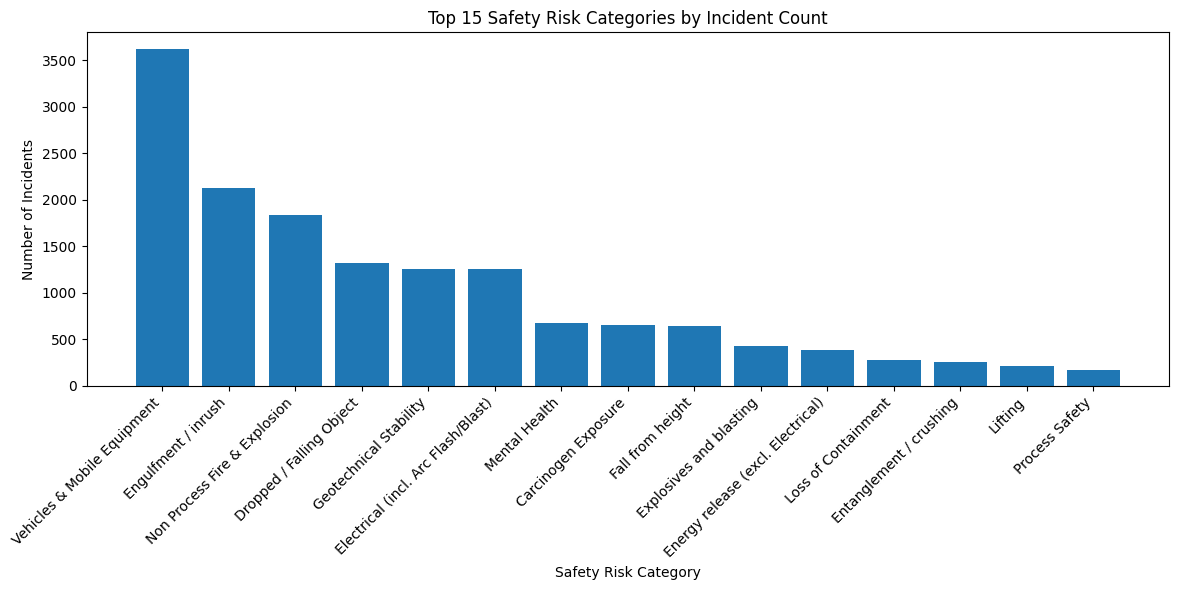

In [4]:

# # Load the data from the MasterData sheet
# df = pd.read_excel("C:\Study Materials\RA-ECU\Events Inc. What Happened_Example data.xlsx", sheet_name="MasterData")

# Compute category counts
cat_counts = df['SAFETY_RISK_CATEGORY'].value_counts()

# Show top 15 categories
top15 = cat_counts.head(15)
print(top15)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(top15.index, top15.values)
plt.title("Top 15 Safety Risk Categories by Incident Count")
plt.xlabel("Safety Risk Category")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# nltk.download("all")


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       tagge

True

In [5]:
## Text Cleanning

stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def clean_text(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemm.lemmatize(t) for t in tokens]
    return tokens
    
df["clean_tokens"] = df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)
df["clean_text"] = df["clean_tokens"].apply(lambda x: " ".join(x))
df.head()


,WHAT_HAPPENED_ENGLISH,SAFETY_RISK_CATEGORY,clean_tokens,clean_text
10,Upon conducting and exit clean housekeepers re...,Mental Health,"[upon, conducting, exit, clean, housekeeper, r...",upon conducting exit clean housekeeper reporte...
18,went to 68 transfer and found chain for tramp ...,Dropped / Falling Object,"[went, transfer, found, chain, tramp, metal, b...",went transfer found chain tramp metal bin chai...
20,Combination lock used on Access gate on KUNZ c...,Fall from height,"[combination, lock, used, access, gate, kunz, ...",combination lock used access gate kunz crane i...
32,A charge up 4X4 with bomb onboard driving pass...,Vehicles & Mobile Equipment,"[charge, bomb, onboard, driving, pas, fuel, ba...",charge bomb onboard driving pas fuel bay headi...
33,While diagnosing an electrical fault with fuel...,Non Process Fire & Explosion,"[diagnosing, electrical, fault, fuel, guage, n...",diagnosing electrical fault fuel guage noticed...


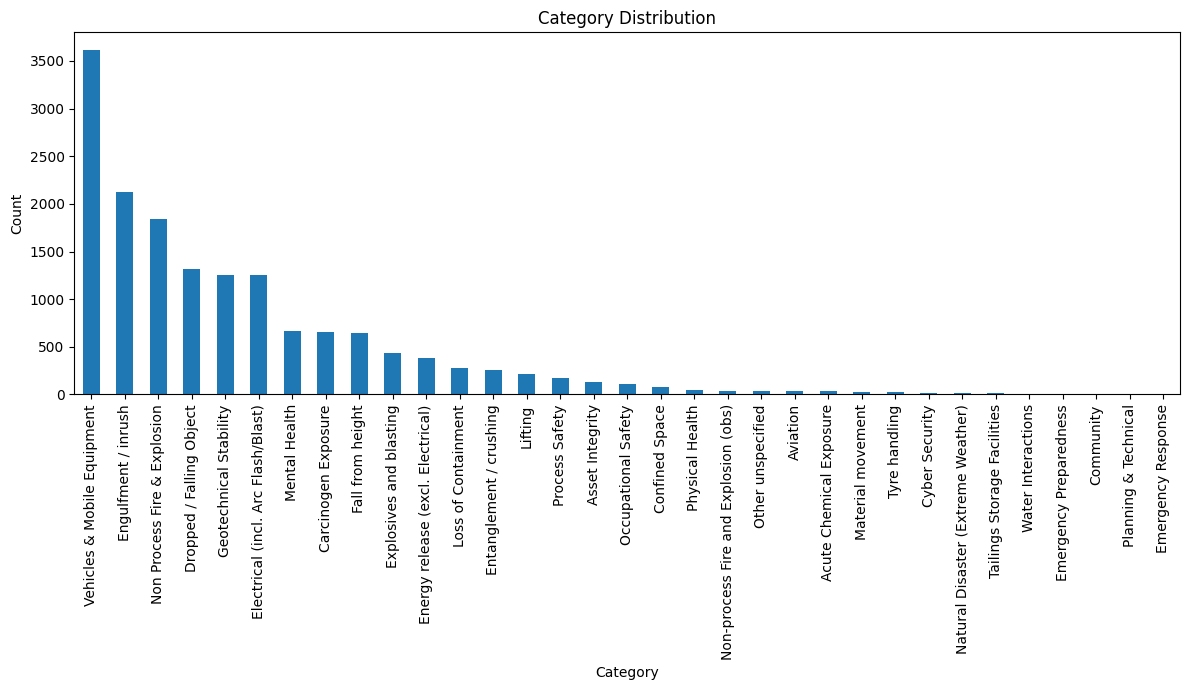

In [6]:
# Category Distribution Plot

plt.figure(figsize=(12,7))
df['SAFETY_RISK_CATEGORY'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [7]:
# Identify Failing Classes

category_counts = df["SAFETY_RISK_CATEGORY"].value_counts()
rare_classes = category_counts[category_counts <= 100]
rare_classes


SAFETY_RISK_CATEGORY
Confined Space                          79
Physical Health                         48
Non-process Fire and Explosion (obs)    41
Other unspecified                       40
Aviation                                38
Acute Chemical Exposure                 37
Material movement                       24
Tyre handling                           22
Cyber Security                          19
Natural Disaster (Extreme Weather)      15
Tailings Storage Facilities             13
Water Interactions                       6
Emergency Preparedness                   4
Community                                1
Planning & Technical                     1
Emergency Response                       1
Name: count, dtype: int64

In [8]:
# Investigate Failing Classes

failing_classes = rare_classes.index.tolist()

for c in failing_classes:
    print("\n=====================================")
    print("Category:", c)
    print("=====================================")
    print(df[df["SAFETY_RISK_CATEGORY"] == c]["WHAT_HAPPENED_ENGLISH"].head(10).to_string())



Category: Confined Space
110     Tails Leach Area Owner discovered the EIM's fo...
301     While undertaking the Confined Space Entry Con...
410     Steel packers found on top of Concentrate Leac...
626     Drain cleaning was carried out on the airport ...
3305    Boiler dust found passing through into Humidif...
3394    It was observed that an isolation associated w...
5778    Whilst conducting field leadership I inspected...
7607    While completing daily checks identified no si...
7670    The confined space entry at Copper Raff Tank w...
8059    A confined space clearance certificate was iss...

Category: Physical Health
143      Contractors scheduled to work in both levels n...
2573            Vent more than 30m from face @ 26 EMR 315.
9791     While in the crib area on lunch break. I notic...
10589    Failed CCO - Covid - 19  Inspected vehicles an...
15015    A resident used the tongs from the fettuccini ...
15054    Identified during Time in Field that the 1W SM...
17371    Resi

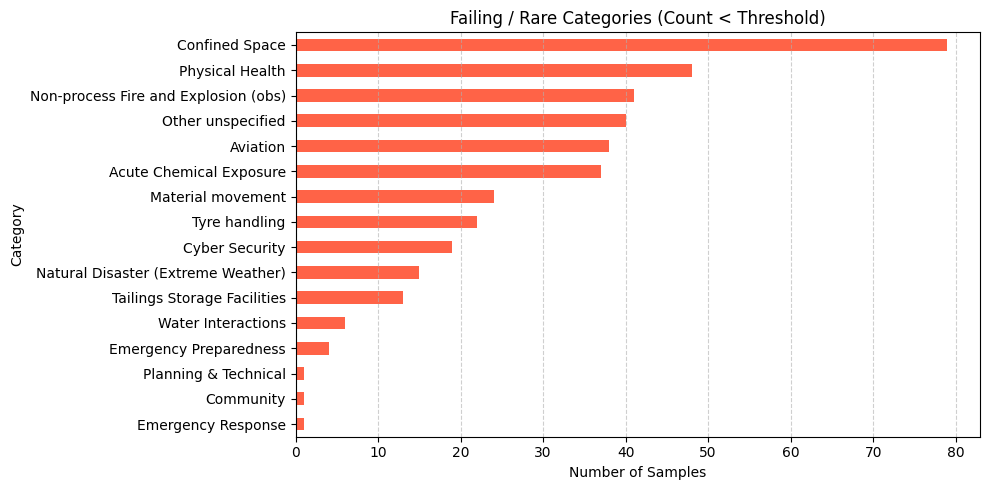

In [9]:

# 📊 Rare / Failing Class Frequency Plot

import matplotlib.pyplot as plt

rare_counts = rare_classes  # already computed earlier

plt.figure(figsize=(10,5))
rare_counts.sort_values().plot(kind='barh', color='tomato')

plt.title("Failing / Rare Categories (Count < Threshold)")
plt.xlabel("Number of Samples")
plt.ylabel("Category")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [10]:
# Group Rare Classes into “Other

counts = df["SAFETY_RISK_CATEGORY"].value_counts()

# threshold for rare classes
threshold = 100
rare_classes = counts[counts < threshold].index.tolist()

df["SAFETY_RISK_CATEGORY"] = df["SAFETY_RISK_CATEGORY"].replace(
    rare_classes, "Other"
)

print("Classes grouped into 'Other':")
rare_classes[:10]


Classes grouped into 'Other':


['Confined Space',
 'Physical Health',
 'Non-process Fire and Explosion (obs)',
 'Other unspecified',
 'Aviation',
 'Acute Chemical Exposure',
 'Material movement',
 'Tyre handling',
 'Cyber Security',
 'Natural Disaster (Extreme Weather)']

In [11]:
# Encode final labels

le = LabelEncoder()
df["label"] = le.fit_transform(df["SAFETY_RISK_CATEGORY"])
df["label"].value_counts()


label
17    3619
5     2128
13    1838
2     1318
9     1258
3     1256
12     669
1      653
8      641
7      430
15     389
4      385
11     273
6      256
10     216
16     168
0      133
14     112
Name: count, dtype: int64

In [12]:
# Train Word2Vec

sentences = df["clean_tokens"].tolist()

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,         # skip-gram for semantic embedding
    workers=4,
    epochs=10
)


In [13]:
# Convert Sentences → Embeddings

def doc_vector(tokens):
    tokens = [t for t in tokens if t in w2v.wv]
    if len(tokens) == 0:
        return np.zeros(100)
    return np.mean(w2v.wv[tokens], axis=0)

X_vectors = np.vstack(df["clean_tokens"].apply(doc_vector))
y = df["label"].values



In [14]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, y,
    test_size=0.2, random_state=42,
    stratify=y
)





In [15]:
# Train Classifier

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=4000)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print(classification_report(y_test, preds, target_names=le.classes_))


                                    precision    recall  f1-score   support

                   Asset Integrity       0.40      0.23      0.29        26
               Carcinogen Exposure       0.75      0.84      0.79       131
          Dropped / Falling Object       0.74      0.79      0.76       264
Electrical (incl. Arc Flash/Blast)       0.74      0.84      0.78       251
 Energy release (excl. Electrical)       0.29      0.08      0.12        77
               Engulfment / inrush       0.83      0.84      0.83       426
           Entanglement / crushing       0.51      0.47      0.49        51
           Explosives and blasting       0.80      0.60      0.69        86
                  Fall from height       0.66      0.53      0.59       128
            Geotechnical Stability       0.75      0.80      0.78       252
                           Lifting       0.72      0.67      0.70        43
               Loss of Containment       0.56      0.64      0.60        55
           

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [16]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

clf_w2v = LogisticRegression(max_iter=3000)
clf_w2v.fit(X_train, y_train)


preds = clf_w2v.predict(X_test)

print(classification_report(y_test, preds))

w2v_accuracy = accuracy_score(y_test, preds)
print("Word2Vec Accuracy:", w2v_accuracy)


              precision    recall  f1-score   support

           0       0.40      0.23      0.29        26
           1       0.75      0.84      0.79       131
           2       0.74      0.79      0.76       264
           3       0.74      0.84      0.78       251
           4       0.29      0.08      0.12        77
           5       0.83      0.84      0.83       426
           6       0.51      0.47      0.49        51
           7       0.80      0.60      0.69        86
           8       0.66      0.53      0.59       128
           9       0.75      0.80      0.78       252
          10       0.72      0.67      0.70        43
          11       0.56      0.64      0.60        55
          12       0.99      0.97      0.98       134
          13       0.73      0.75      0.74       368
          14       0.00      0.00      0.00        22
          15       0.45      0.29      0.36        78
          16       0.50      0.27      0.35        33
          17       0.82    

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
# w2v_report = classification_report(y_test, preds, output_dict=True)
# w2v_precision = w2v_report["macro avg"]["precision"]
# w2v_recall = w2v_report["macro avg"]["recall"]
# w2v_f1 = w2v_report["macro avg"]["f1-score"]


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [103]:
# word clouds for good and bad classes

def plot_wordcloud(category):
    text = " ".join(df[df['SAFETY_RISK_CATEGORY'] == category]["clean_text"])
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud: {category}")
    plt.show()


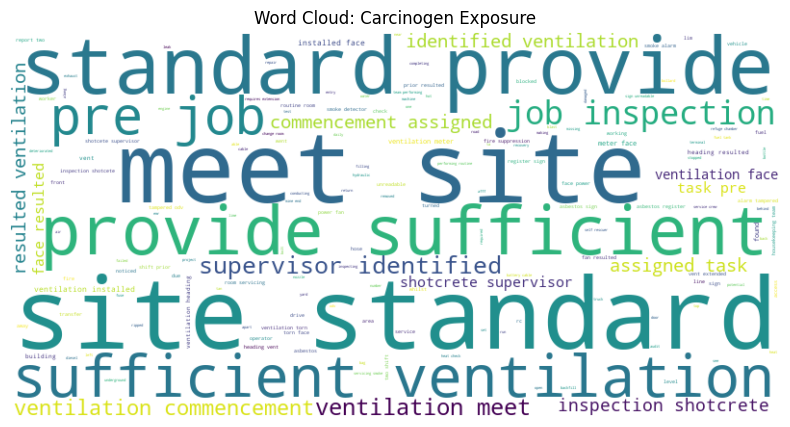

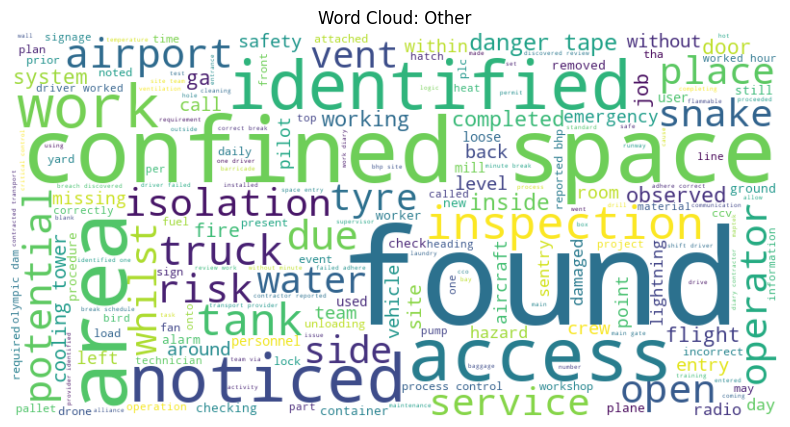

In [104]:
plot_wordcloud("Carcinogen Exposure")   # Good class
plot_wordcloud("Other")                  # Likely poor-performing class


In [105]:
#TF-IDF (1–2 gram) + Logistic Regression
print("Running TF-IDF (1-2 grams)…")

texts = df["clean_text"]  ## prepare text labels
labels = df["label"]

# Train/test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),    # unigrams + bigrams
    max_features=5000,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("TF-IDF shape:", X_train_tfidf.shape)

tfidf_clf = LogisticRegression(
    max_iter=4000,
    class_weight='balanced'  
)

tfidf_clf.fit(X_train_tfidf, y_train)

preds_tfidf = tfidf_clf.predict(X_test_tfidf)

#  Classification Report

print("\n=== TF-IDF (1–2 gram) Classification Report ===\n")
print(classification_report(y_test, preds_tfidf, target_names=le.classes_))

from sklearn.metrics import accuracy_score
tfidf_accuracy = accuracy_score(y_test, preds_tfidf)
print("TF-IDF Accuracy:", tfidf_accuracy)

Running TF-IDF (1-2 grams)…
TF-IDF shape: (12593, 5000)

=== TF-IDF (1–2 gram) Classification Report ===

                                    precision    recall  f1-score   support

                   Asset Integrity       0.41      0.50      0.45        26
               Carcinogen Exposure       0.76      0.86      0.81       131
          Dropped / Falling Object       0.87      0.74      0.80       264
Electrical (incl. Arc Flash/Blast)       0.76      0.87      0.81       251
 Energy release (excl. Electrical)       0.24      0.27      0.26        77
               Engulfment / inrush       0.94      0.84      0.89       426
           Entanglement / crushing       0.39      0.67      0.49        51
           Explosives and blasting       0.79      0.79      0.79        86
                  Fall from height       0.65      0.74      0.69       128
            Geotechnical Stability       0.82      0.85      0.83       252
                           Lifting       0.65      0.91  

In [ ]:
# from sklearn.metrics import classification_report
# tfidf_report = classification_report(y_test, preds_tfidf, output_dict=True)
# tfidf_precision = tfidf_report["macro avg"]["precision"]
# tfidf_recall = tfidf_report["macro avg"]["recall"]
# tfidf_f1 = tfidf_report["macro avg"]["f1-score"]


Excel file saved: tfidf_classification_report.xlsx


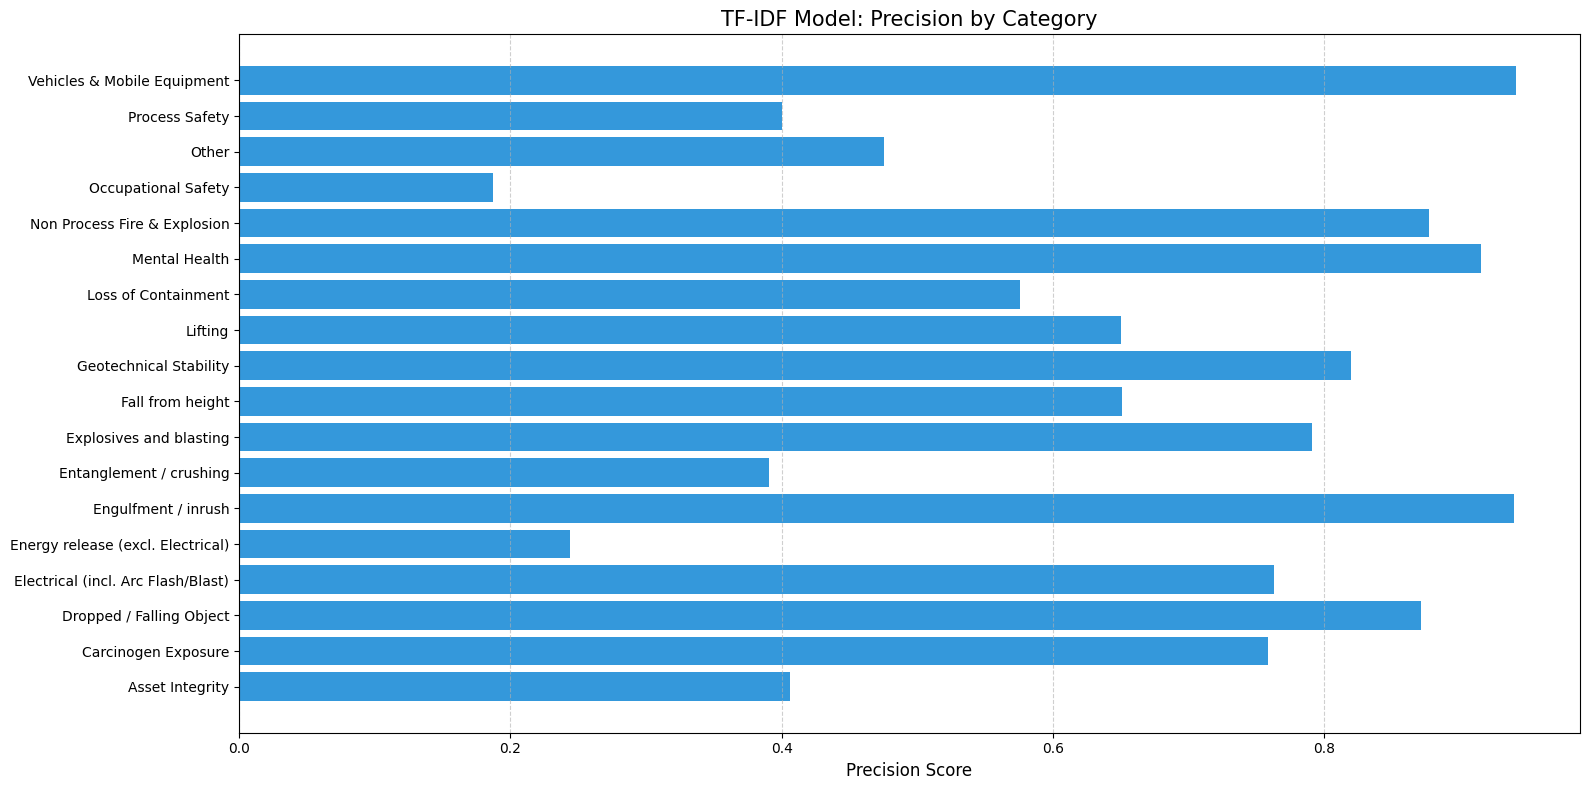

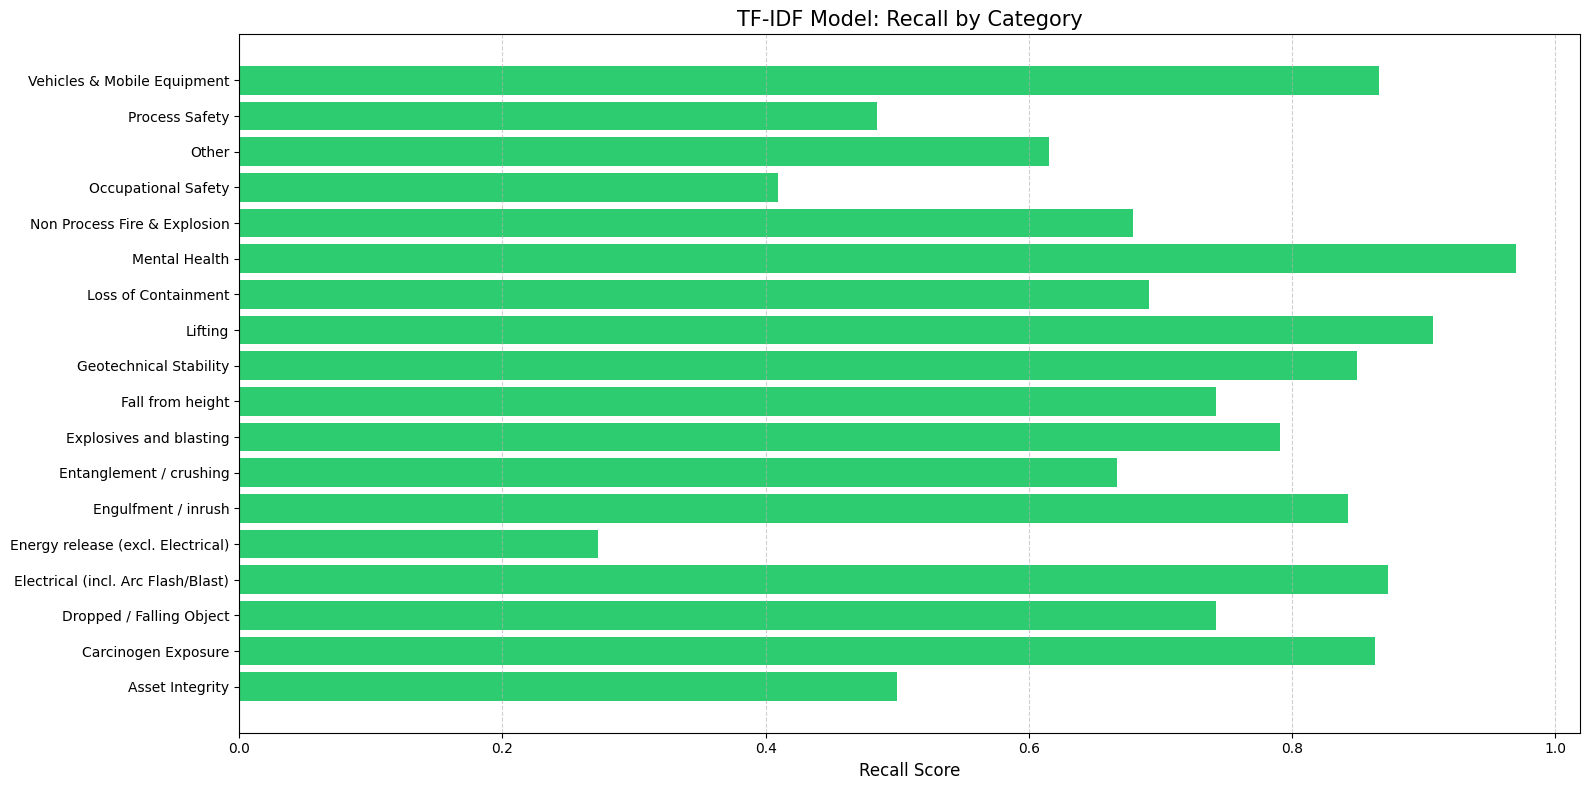

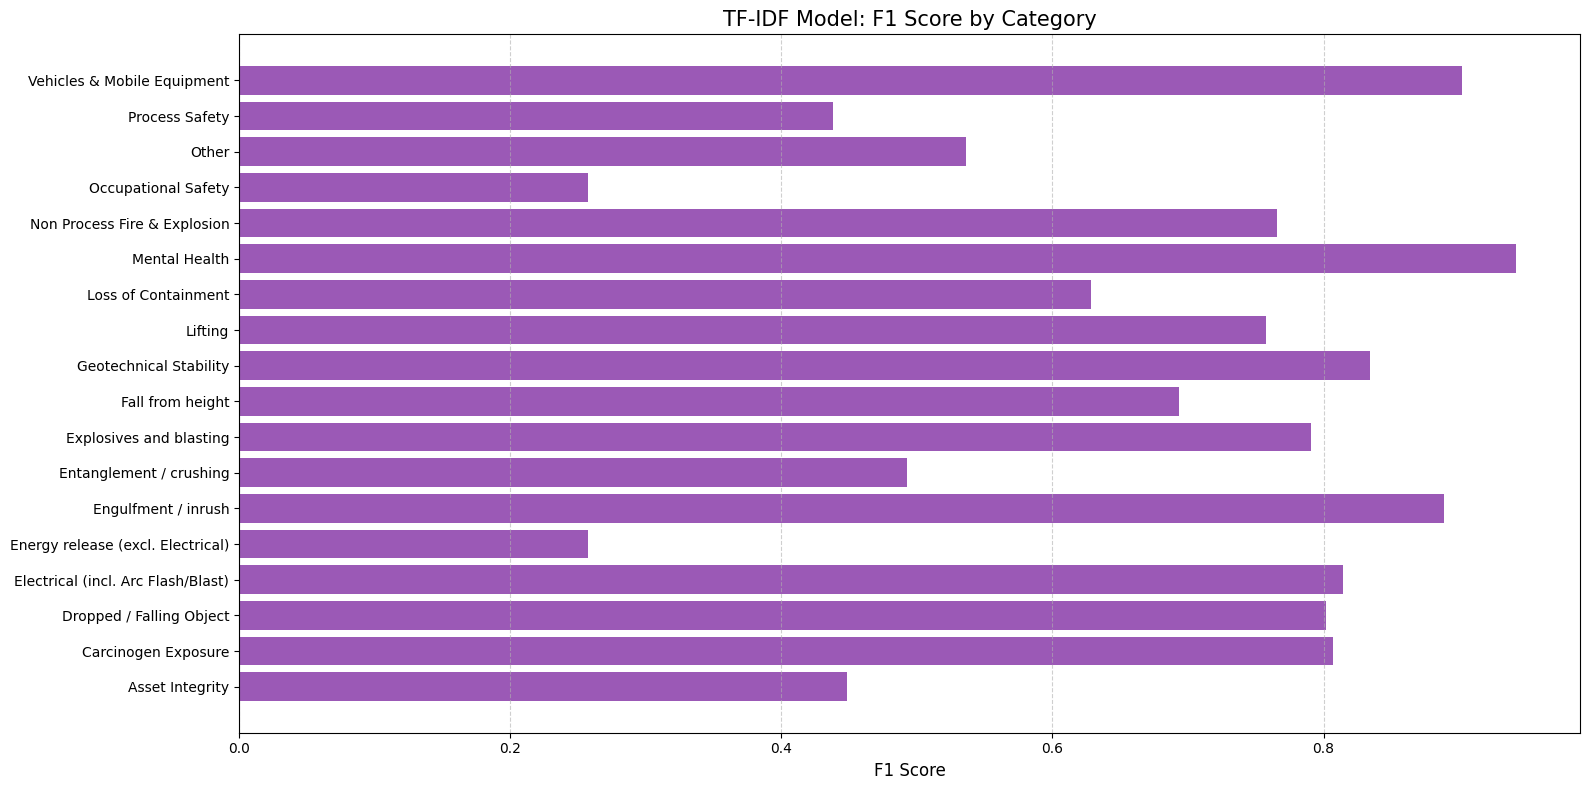

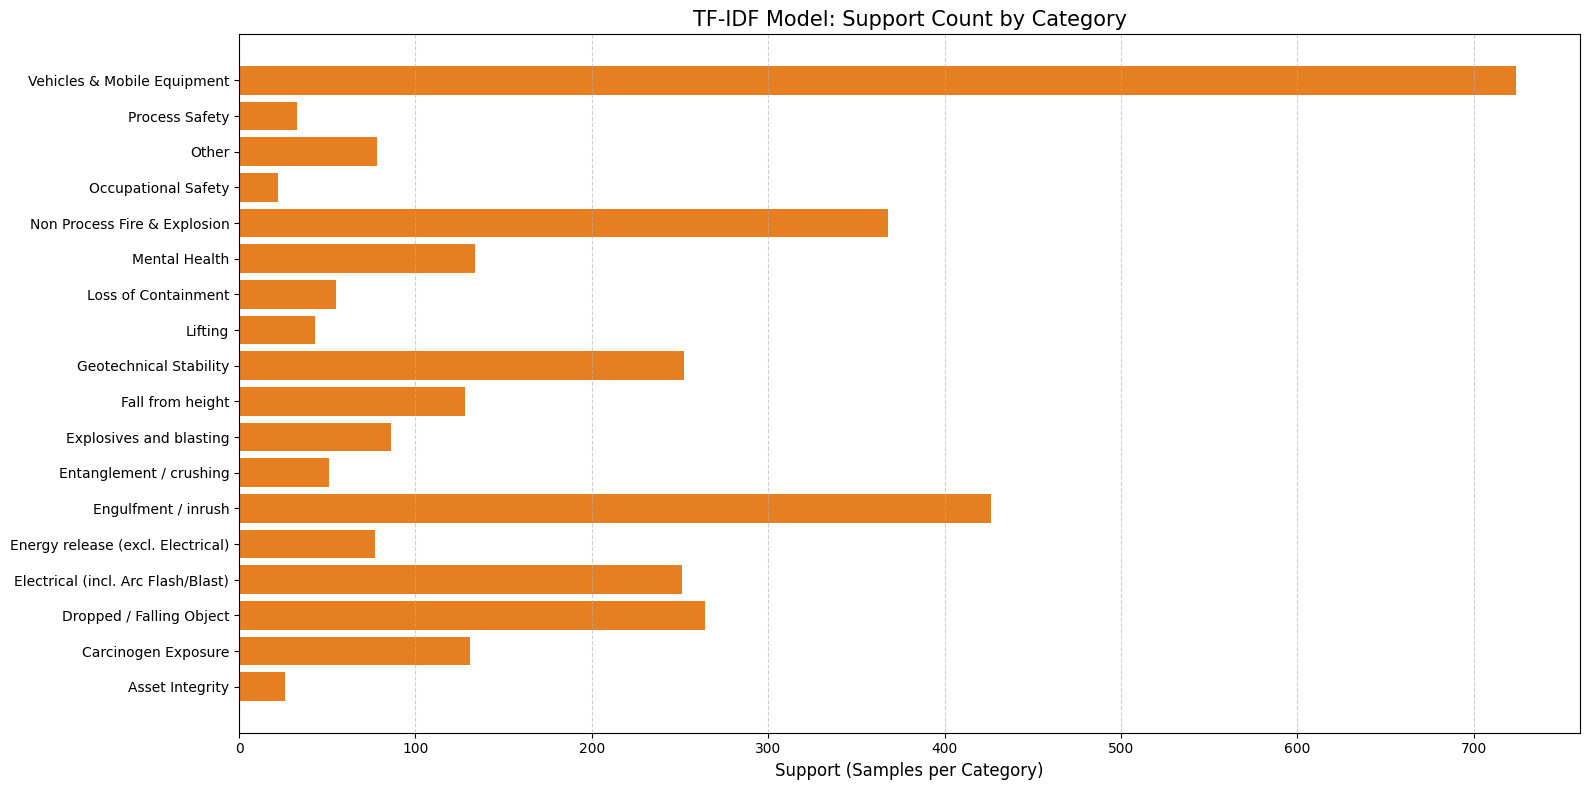

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# -------------------------------------------------------------
# Convert classification report to DataFrame
# -------------------------------------------------------------
report = classification_report(
    y_test,
    preds_tfidf,
    target_names=le.classes_,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

# Save to Excel
output_path = "tfidf_classification_report.xlsx"
df_report.to_excel(output_path, index=True)
print(f"Excel file saved: {output_path}")

# -------------------------------------------------------------
# Remove the last 3 rows (accuracy, macro avg, weighted avg)
# Keep only category rows
# -------------------------------------------------------------
df_class_only = df_report.iloc[:-3]

# -------------------------------------------------------------
# Plot function
# -------------------------------------------------------------
def plot_metric(metric_name, ylabel, title, color):
    plt.figure(figsize=(16, 8))
    plt.barh(df_class_only.index, df_class_only[metric_name], color=color)
    plt.xlabel(ylabel, fontsize=12)
    plt.title(title, fontsize=15)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# 4 Required Plots
# -------------------------------------------------------------
plot_metric("precision",
            "Precision Score",
            "TF-IDF Model: Precision by Category",
            "#3498db")

plot_metric("recall",
            "Recall Score",
            "TF-IDF Model: Recall by Category",
            "#2ecc71")

plot_metric("f1-score",
            "F1 Score",
            "TF-IDF Model: F1 Score by Category",
            "#9b59b6")

plot_metric("support",
            "Support (Samples per Category)",
            "TF-IDF Model: Support Count by Category",
            "#e67e22")


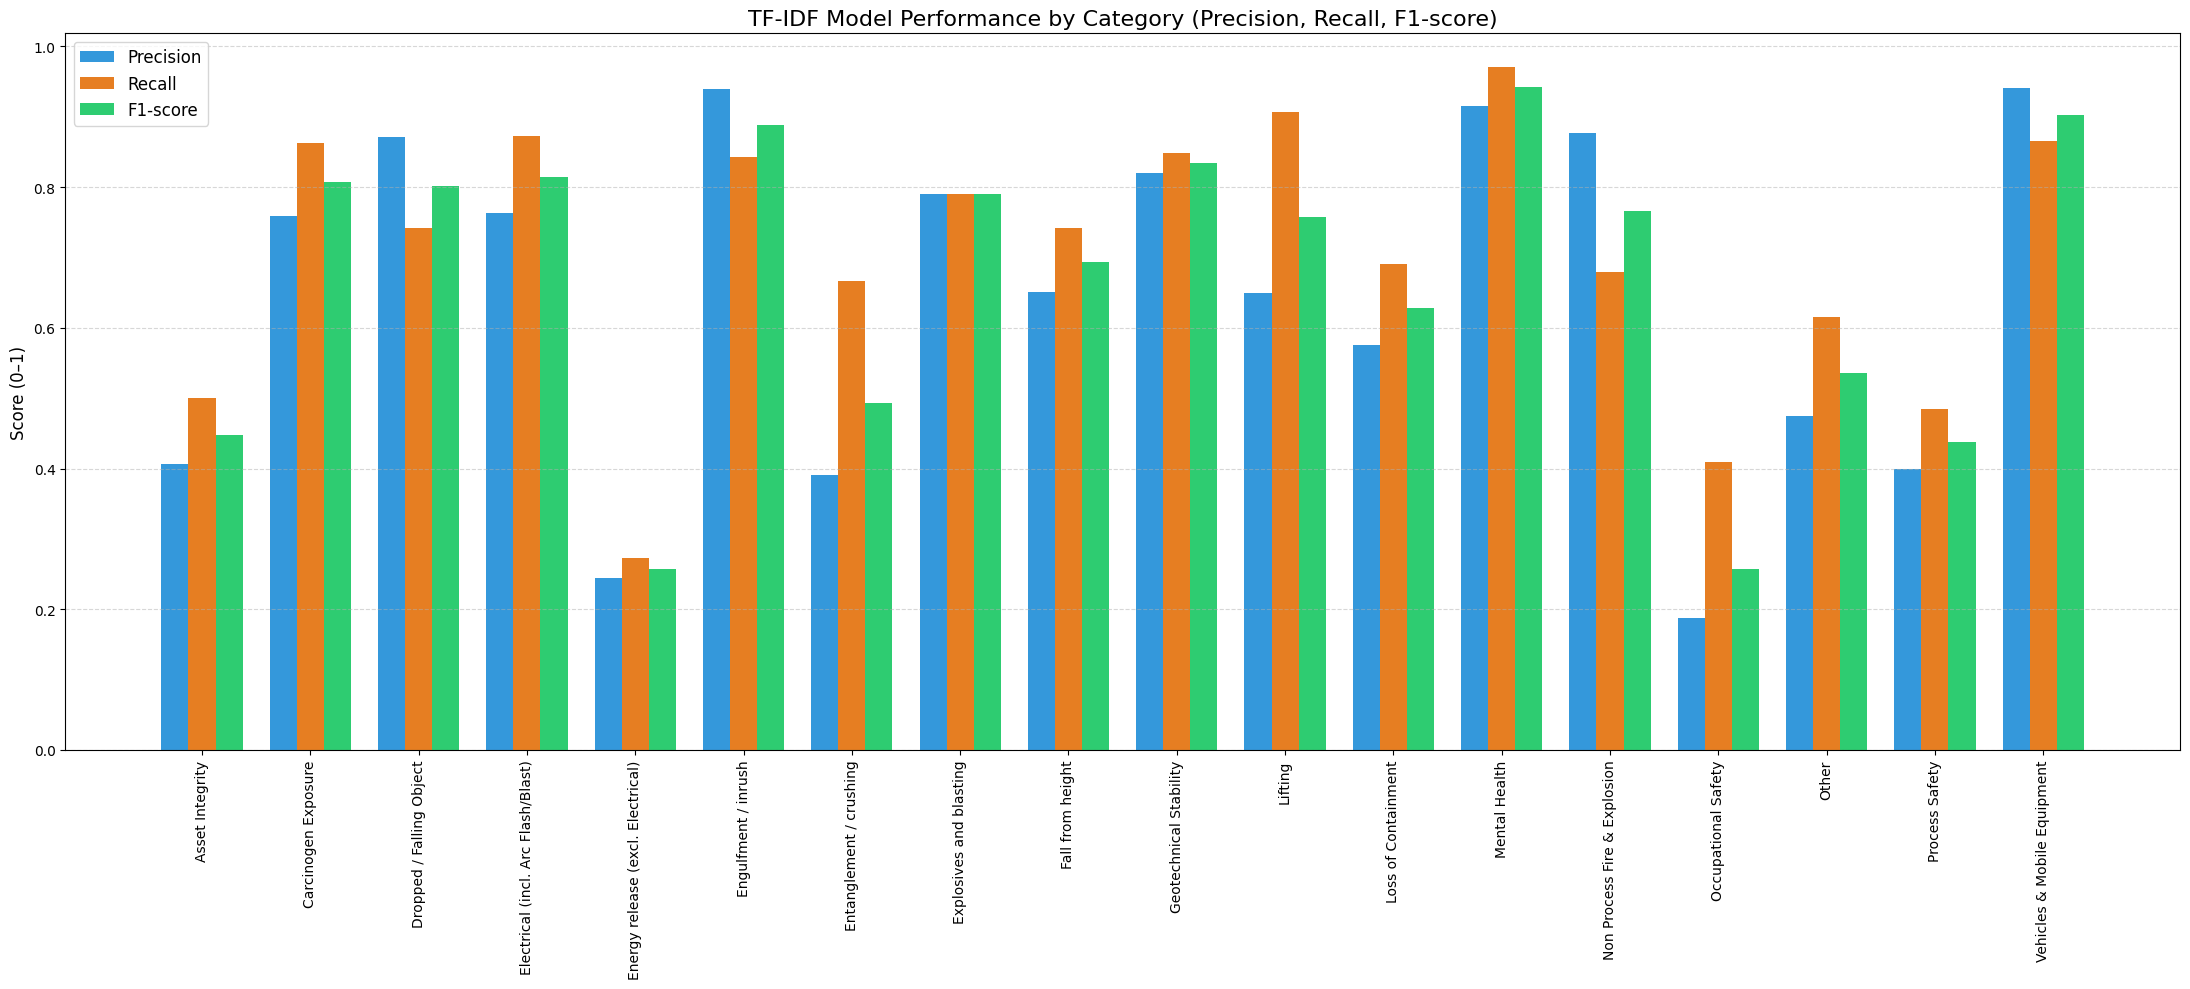

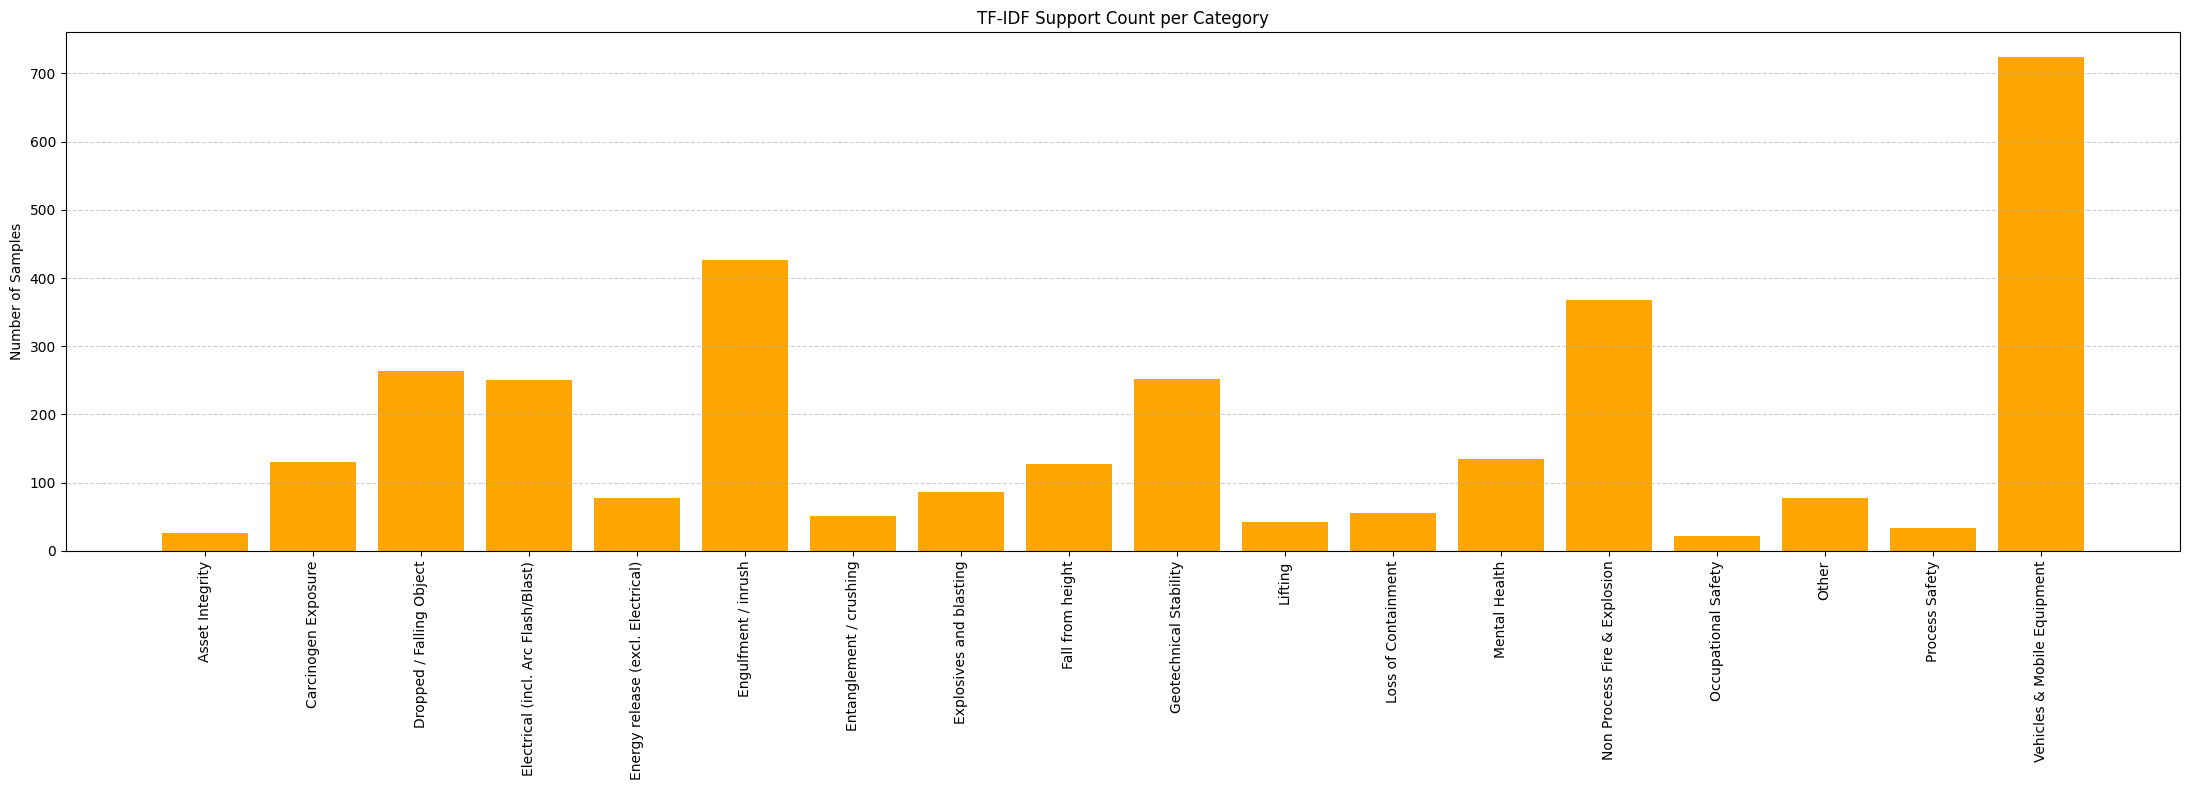

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# -------------------------------------------------------------
# Convert classification report to DataFrame
# -------------------------------------------------------------
report = classification_report(
    y_test,
    preds_tfidf,
    target_names=le.classes_,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

# # Save Excel
# output_path = "tfidf_classification_report.xlsx"
# df_report.to_excel(output_path, index=True)
# print(f"Excel file saved: {output_path}")

# -------------------------------------------------------------
# Keep only category rows (remove accuracy/macro/weighted rows)
# -------------------------------------------------------------
df_class_only = df_report.iloc[:-3].copy()

# -------------------------------------------------------------
# BAR CHART for Precision / Recall / F1-score
# -------------------------------------------------------------
metrics = ["precision", "recall", "f1-score"]
colors = ["#3498db", "#e67e22", "#2ecc71"]

x = np.arange(len(df_class_only))           # category positions
width = 0.25                                # bar width

plt.figure(figsize=(22, 10))

# Plot one bar per metric
for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        df_class_only[metric],
        width,
        label=metric.capitalize(),
        color=colors[i]
    )

plt.xticks(x + width, df_class_only.index, rotation=90)
plt.ylabel("Score (0–1)", fontsize=12)
plt.title("TF-IDF Model Performance by Category (Precision, Recall, F1-score)", fontsize=16)

plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# SUPPORT BAR CHART (unchanged)
# -------------------------------------------------------------
plt.figure(figsize=(22, 8))
plt.bar(df_class_only.index, df_class_only["support"], color="orange")

plt.xticks(rotation=90)
plt.ylabel("Number of Samples")
plt.title("TF-IDF Support Count per Category")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [108]:
print("Train size W2V:", len(X_train))
print("Test size W2V:", len(X_test))

print("Train size TF-IDF:", len(X_train_text))
print("Test size TF-IDF:", len(X_test_text))


Train size W2V: 12593
Test size W2V: 3149
Train size TF-IDF: 12593
Test size TF-IDF: 3149


In [109]:

from gensim.models import FastText
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np


# 1. Train FastText model (gensim version, CPU-friendly)

fasttext_model = FastText(
    sentences=df["clean_tokens"],
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,        # Skip-gram
    workers=4,
    epochs=10
)

print("FastText model trained.")

# 2. Sentence vector (mean embedding)

def get_ft_vector(tokens):
    vectors = []
    for t in tokens:
        if t in fasttext_model.wv:
            vectors.append(fasttext_model.wv[t])
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_ft = np.vstack(df["clean_tokens"].apply(get_ft_vector))

print("FastText vectors created:", X_ft.shape)

# Split (same X_train, X_test from earlier!)

from sklearn.model_selection import train_test_split

X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_ft,
    df["label"],
    test_size=0.1,
    random_state=42,
    stratify=df["label"]
)

# 4. Train classifier

clf_ft = LogisticRegression(max_iter=2000)
clf_ft.fit(X_train_ft, y_train_ft)

#  Evaluate
y_pred_ft = clf_ft.predict(X_test_ft)

print("\n=== FastText Classification Report ===\n")
print(classification_report(y_test_ft, y_pred_ft, zero_division=0))

from sklearn.metrics import accuracy_score
ft_accuracy = accuracy_score(y_test_ft, y_pred_ft)
print("FastText Accuracy:", ft_accuracy)


FastText model trained.
FastText vectors created: (15742, 100)

=== FastText Classification Report ===

              precision    recall  f1-score   support

           0       0.50      0.31      0.38        13
           1       0.75      0.85      0.80        65
           2       0.71      0.77      0.74       132
           3       0.69      0.81      0.75       126
           4       0.67      0.21      0.32        38
           5       0.83      0.84      0.84       213
           6       0.62      0.50      0.55        26
           7       0.93      0.60      0.73        43
           8       0.71      0.58      0.64        64
           9       0.81      0.86      0.83       126
          10       0.67      0.73      0.70        22
          11       0.50      0.56      0.53        27
          12       0.98      0.97      0.98        67
          13       0.79      0.74      0.76       184
          14       0.00      0.00      0.00        11
          15       0.48      0.

In [ ]:
# ft_report = classification_report(y_test_ft, y_pred_ft, output_dict=True)
# ft_precision = ft_report["macro avg"]["precision"]
# ft_recall = ft_report["macro avg"]["recall"]
# ft_f1 = ft_report["macro avg"]["f1-score"]


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [ ]:
# model_names = ["Word2Vec", "TF-IDF", "FastText"]
# accuracies = [w2v_accuracy, tfidf_accuracy, ft_accuracy]


Word2Vec Accuracy: 0.7662750079390283
TF-IDF Accuracy: 0.7904096538583677
FastText Accuracy: 0.7752380952380953


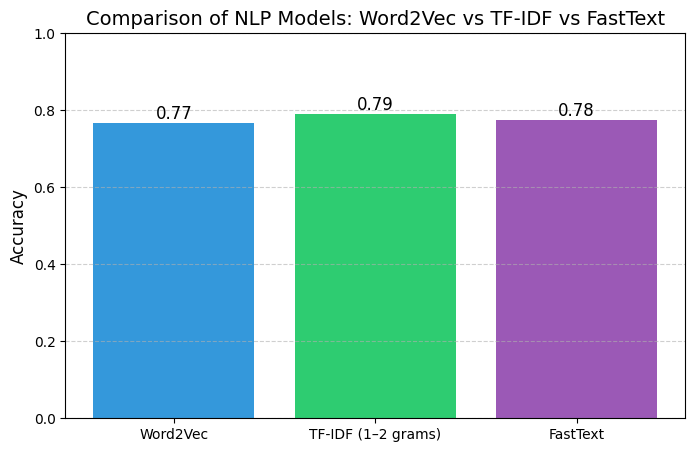

In [110]:

# Comparison of NLP Models


import matplotlib.pyplot as plt

print("Word2Vec Accuracy:", w2v_accuracy)
print("TF-IDF Accuracy:", tfidf_accuracy)
print("FastText Accuracy:", ft_accuracy)

model_names = ["Word2Vec", "TF-IDF (1–2 grams)", "FastText"]
accuracies = [w2v_accuracy, tfidf_accuracy, ft_accuracy]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=["#3498db", "#2ecc71", "#9b59b6"])

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 0.01, 
        f"{acc:.2f}", 
        ha="center", 
        fontsize=12
    )

plt.ylabel("Accuracy", fontsize=12)
plt.title("Comparison of NLP Models: Word2Vec vs TF-IDF vs FastText", fontsize=14)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split

# # Keep only raw columns
# df_raw = df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].copy()

# # Count categories
# class_counts = df_raw['SAFETY_RISK_CATEGORY'].value_counts()

# # Identify rare classes
# rare_classes = class_counts[class_counts < 10].index.tolist()   # <2 because stratify needs min 2
# df_raw['is_rare'] = df_raw['SAFETY_RISK_CATEGORY'].isin(rare_classes)
# df_raw['is_failing'] = df_raw['is_rare']

# # Split data: first separate rare and non-rare samples
# df_rare = df_raw[df_raw['is_rare']]
# df_nonrare = df_raw[~df_raw['is_rare']]

# # Now stratify ONLY on non-rare categories
# train_main, test_main = train_test_split(
#     df_nonrare,
#     test_size=0.20,
#     random_state=42,
#     stratify=df_nonrare['SAFETY_RISK_CATEGORY']
# )

# # Add ALL rare classes to the test set (so client can inspect them)
# test_raw = pd.concat([test_main, df_rare], ignore_index=True)

# # Final train set = stratified non-rare only
# train_raw = train_main.reset_index(drop=True)
# test_raw = test_raw.reset_index(drop=True)

# # Export
# train_raw.to_excel("training_raw_with_flags.xlsx", index=False)
# test_raw.to_excel("test_raw_with_flags.xlsx", index=False)

# print("Exported:")
# print("training_raw_with_flags1.xlsx")
# print("test_raw_with_flags1.xlsx")


Exported:
training_raw_with_flags1.xlsx
test_raw_with_flags1.xlsx


In [111]:
# ============================================
# 1. Imports
# ============================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ============================================
# 2. Load Data
# ============================================
df = pd.read_excel("C:\Study Materials\RA-ECU\Events Inc. What Happened_Example data.xlsx", sheet_name="MasterData")
df = df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].dropna()

# ============================================
# 3. Group Rare Categories
# ============================================
counts = df['SAFETY_RISK_CATEGORY'].value_counts()
rare_classes = counts[counts < 100].index.tolist()

print("\nRare Classes Grouped into 'Other':")
print(rare_classes)

df['SAFETY_RISK_CATEGORY'] = df['SAFETY_RISK_CATEGORY'].apply(
    lambda x: 'Other' if x in rare_classes else x
)

# ============================================
# 4. Encode Labels
# ============================================
le = LabelEncoder()
df['label'] = le.fit_transform(df['SAFETY_RISK_CATEGORY'])

print("\nFinal Categories:", list(le.classes_))
print("Total number of categories =", len(le.classes_))

# ============================================
# 5. Train-Test Split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    df['WHAT_HAPPENED_ENGLISH'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# ============================================
# 6. Tokenization
# ============================================
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)

num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# ============================================
# 7. Build CNN Model
# ============================================
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nCNN Model Summary:")
model.summary()

# ============================================
# 8. Train CNN
# ============================================
history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=6,
    batch_size=32,
    verbose=1
)

# ============================================
# 9. Evaluate CNN
# ============================================
pred_probs = model.predict(X_test_pad)
pred_labels = np.argmax(pred_probs, axis=1)

print("\n=== CNN Classification Report ===\n")
print(classification_report(y_test, pred_labels, target_names=le.classes_))

cnn_accuracy = accuracy_score(y_test, pred_labels)
print("CNN Accuracy:", cnn_accuracy)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)



Rare Classes Grouped into 'Other':
['Confined Space', 'Physical Health', 'Non-process Fire and Explosion (obs)', 'Other unspecified', 'Aviation', 'Acute Chemical Exposure', 'Material movement', 'Tyre handling', 'Cyber Security', 'Natural Disaster (Extreme Weather)', 'Tailings Storage Facilities', 'Water Interactions', 'Emergency Preparedness', 'Community', 'Planning & Technical', 'Emergency Response']

Final Categories: ['Asset Integrity', 'Carcinogen Exposure', 'Dropped / Falling Object', 'Electrical (incl. Arc Flash/Blast)', 'Energy release (excl. Electrical)', 'Engulfment / inrush', 'Entanglement / crushing', 'Explosives and blasting', 'Fall from height', 'Geotechnical Stability', 'Lifting', 'Loss of Containment', 'Mental Health', 'Non Process Fire & Explosion', 'Occupational Safety', 'Other', 'Process Safety', 'Vehicles & Mobile Equipment']
Total number of categories = 18


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



CNN Model Summary:


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_11         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.5175 - loss: 1.6896 - val_accuracy: 0.7095 - val_loss: 1.0465
Epoch 2/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.7619 - loss: 0.8598 - val_accuracy: 0.7730 - val_loss: 0.8498
Epoch 3/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8502 - loss: 0.5382 - val_accuracy: 0.7881 - val_loss: 0.8257
Epoch 4/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9106 - loss: 0.3252 - val_accuracy: 0.7984 - val_loss: 0.8708
Epoch 5/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9462 - loss: 0.1945 - val_accuracy: 0.7905 - val_loss: 0.9828
Epoch 6/6
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9673 - loss: 0.1242 - val_accuracy: 0.7825 - val_loss: 1.0640
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== CNN Classification Report ===

                                    precision    recall  f1-score   support

                   Asset Integrity       0.54      0.27      0.36        26
  

In [112]:
model.build(input_shape=(None, MAX_LEN))
model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 96, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_11         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,954,424 (30.34 MB)

 Trainable params: 2,651,474 (10.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,302,950 (20.23 MB)

In [ ]:
# cnn_report = classification_report(y_test, pred_labels, output_dict=True)
# cnn_precision = cnn_report["macro avg"]["precision"]
# cnn_recall = cnn_report["macro avg"]["recall"]
# cnn_f1 = cnn_report["macro avg"]["f1-score"]


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Word2Vec Accuracy: 0.7662750079390283
TF-IDF Accuracy: 0.7904096538583677
FastText Accuracy: 0.7752380952380953
CNN Accuracy: 0.7878691648142268


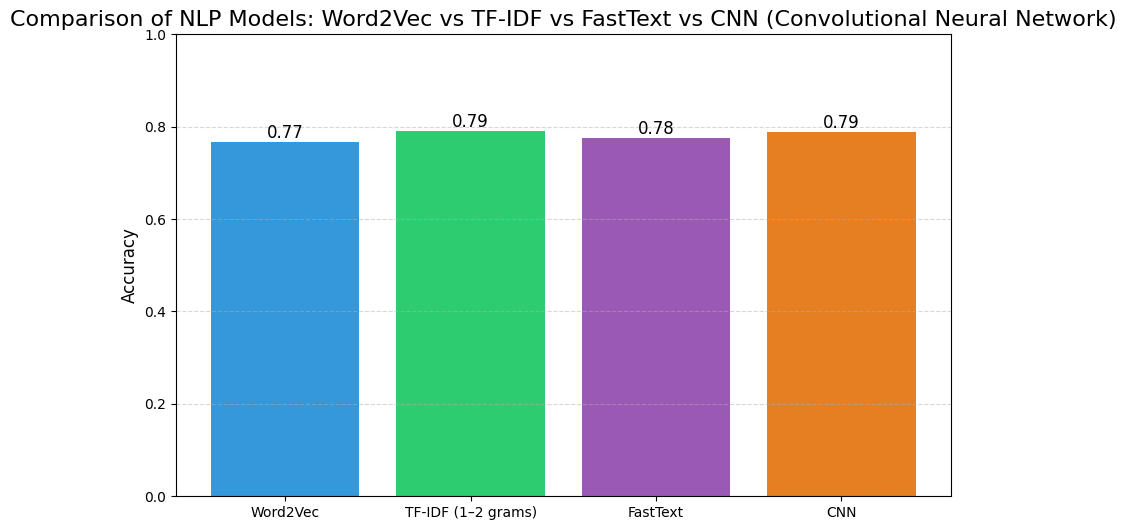

In [113]:
import matplotlib.pyplot as plt

# Print all accuracies
print("Word2Vec Accuracy:", w2v_accuracy)
print("TF-IDF Accuracy:", tfidf_accuracy)
print("FastText Accuracy:", ft_accuracy)
print("CNN Accuracy:", cnn_accuracy)

# Model names and accuracy list
model_names = ["Word2Vec", "TF-IDF (1–2 grams)", "FastText", "CNN"]
accuracies = [w2v_accuracy, tfidf_accuracy, ft_accuracy, cnn_accuracy]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=["#3498db", "#2ecc71", "#9b59b6", "#e67e22"])

# Add accuracy labels above bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha="center",
        fontsize=12
    )

plt.ylabel("Accuracy", fontsize=12)
plt.title("Comparison of NLP Models: Word2Vec vs TF-IDF vs FastText vs CNN (Convolutional Neural Network)", fontsize=16)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


In [ ]:
# df_report.to_excel(output_path, index=True)
# print(f"Excel file saved: {output_path}")

In [ ]:
# model_names = ["Word2Vec", "TF-IDF", "FastText", "CNN"]

# precision_scores = [w2v_precision, tfidf_precision, ft_precision, cnn_precision]
# recall_scores    = [w2v_recall,    tfidf_recall,    ft_recall,    cnn_recall]
# f1_scores        = [w2v_f1,        tfidf_f1,        ft_f1,        cnn_f1]


In [ ]:
# print (precision_scores)
# print (f1_scores)

[0.4858906386727784, 0.5457715280840432, 0.5476333006855597, 0.5076187002116386]
[0.4099529199679811, 0.5636370484348253, 0.4313586837944381, 0.47347589627189796]


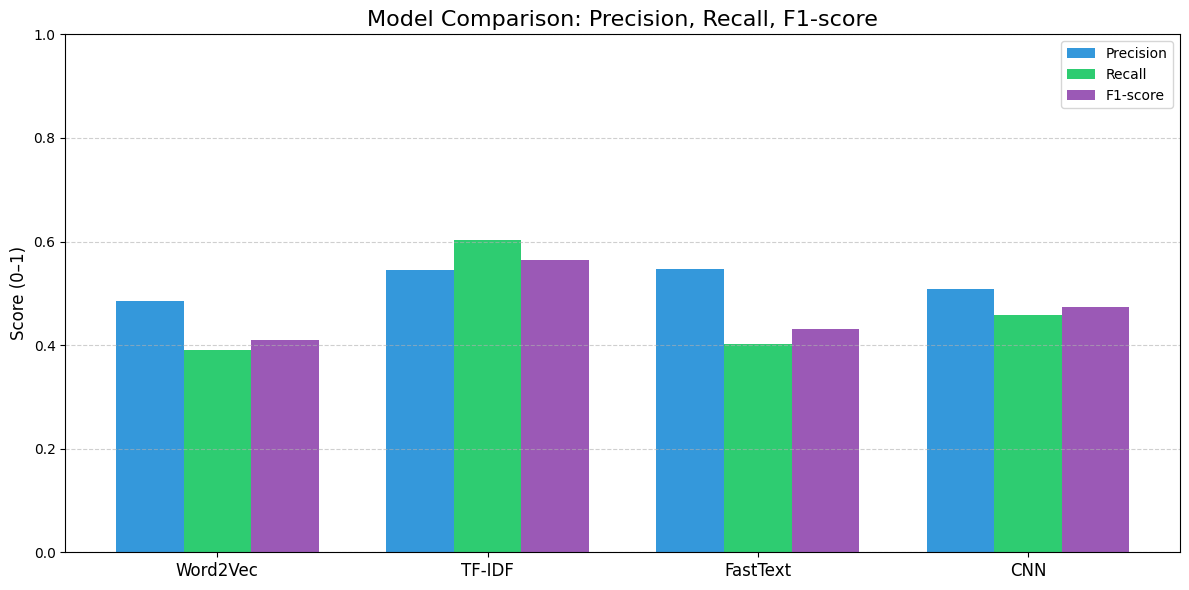

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# x = np.arange(len(model_names))  # positions
# width = 0.25  # bar width

# plt.figure(figsize=(12, 6))

# # Bars
# plt.bar(x - width, precision_scores, width, label='Precision', color="#3498db")
# plt.bar(x,         recall_scores,    width, label='Recall',    color="#2ecc71")
# plt.bar(x + width, f1_scores,        width, label='F1-score',  color="#9b59b6")

# # Labels
# plt.xticks(x, model_names, fontsize=12)
# plt.ylabel("Score (0–1)", fontsize=12)
# plt.ylim(0, 1)

# plt.title("Model Comparison: Precision, Recall, F1-score", fontsize=16)
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.6)

# plt.tight_layout()
# plt.show()


In [114]:
# ============================================
# 1. Imports
# ============================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from gensim.models import FastText

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# (run these once if you haven't already)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

# For reproducibility
import tensorflow as tf
import random, os
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# 2. Load Data
# ============================================
df = pd.read_excel(
    r"C:/Study Materials/RA-ECU/Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)

df = df[['WHAT_HAPPENED_ENGLISH', 'SAFETY_RISK_CATEGORY']].dropna()

print("Total rows after dropping NA:", len(df))

# ============================================
# 3. Text Cleaning (same as before)
# ============================================
stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def clean_text(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]          # keep only words
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemm.lemmatize(t) for t in tokens]         # lemmatize
    return tokens

df["clean_tokens"] = df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)

# ============================================
# 4. Merge Rare Classes (< 100) into "Other"
# ============================================
counts = df['SAFETY_RISK_CATEGORY'].value_counts()
rare_classes = counts[counts < 100].index.tolist()

print("Number of original classes:", len(counts))
print("Rare classes (<100):", len(rare_classes))

df['SAFETY_RISK_CATEGORY'] = df['SAFETY_RISK_CATEGORY'].apply(
    lambda x: "Other" if x in rare_classes else x
)

# Re-check class distribution after merging
print("\nClass distribution after merging rare classes:")
print(df['SAFETY_RISK_CATEGORY'].value_counts())

# ============================================
# 5. Label Encode Categories
# ============================================
le = LabelEncoder()
df['label'] = le.fit_transform(df['SAFETY_RISK_CATEGORY'])

num_classes = len(le.classes_)
print("\nFinal number of classes:", num_classes)
print("Classes:", le.classes_)

# ============================================
# 6. Train-Test Split (STRATIFIED)
# ============================================
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    df["clean_tokens"],
    df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

print("\nTrain size:", len(X_train_tokens), " Test size:", len(X_test_tokens))

# ============================================
# 7. Train FastText model on *all* cleaned tokens
# ============================================
fasttext_model = FastText(
    sentences=df["clean_tokens"],
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,        # skip-gram
    workers=4,
    epochs=10
)

print("\nFastText trained.")
print("FastText vocab size:", len(fasttext_model.wv))

# ============================================
# 8. Tokenizer for CNN (aligned with clean_tokens)
# ============================================
MAX_WORDS = 20000
MAX_LEN = 100
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
# join tokens back to text for tokenizer
tokenizer.fit_on_texts(df["clean_tokens"].apply(lambda x: " ".join(x)))

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index)) + 1

print("Tokenizer vocab size (capped):", vocab_size)

# Convert train/test tokens to padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_tokens)
X_test_seq = tokenizer.texts_to_sequences(X_test_tokens)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN)

print("Padded shapes -> train:", X_train_pad.shape, " test:", X_test_pad.shape)

# ============================================
# 9. Build FastText Embedding Matrix
# ============================================
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype="float32")

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in fasttext_model.wv:
        embedding_matrix[i] = fasttext_model.wv[word]
    else:
        # OOV for FastText: small random vector
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

print("Embedding matrix shape:", embedding_matrix.shape)

# ============================================
# 10. Prepare Labels (one-hot)
# ============================================
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ============================================
# 11. CNN Model with Trainable FastText Embeddings
# ============================================
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True            # <--- IMPORTANT: allow fine-tuning
    ),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nCNN + FastText Model Summary:")
model.summary()

# ============================================
# 12. Train with EarlyStopping
# ============================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=20,             # more epochs than before
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ============================================
# 13. Evaluation
# ============================================
pred_probs = model.predict(X_test_pad)
pred_labels = np.argmax(pred_probs, axis=1)

print("\n=== CNN + FastText (Improved) Classification Report ===\n")
print(classification_report(y_test, pred_labels, target_names=le.classes_))

cnn_ft_accuracy = accuracy_score(y_test, pred_labels)
print("Improved CNN + FastText Accuracy:", cnn_ft_accuracy)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Total rows after dropping NA: 15742
Number of original classes: 33
Rare classes (<100): 16

Class distribution after merging rare classes:
SAFETY_RISK_CATEGORY
Vehicles & Mobile Equipment           3619
Engulfment / inrush                   2128
Non Process Fire & Explosion          1838
Dropped / Falling Object              1318
Geotechnical Stability                1258
Electrical (incl. Arc Flash/Blast)    1256
Mental Health                          669
Carcinogen Exposure                    653
Fall from height                       641
Explosives and blasting                430
Other                                  389
Energy release (excl. Electrical)      385
Loss of Containment                    273
Entanglement / crushing                256
Lifting                                216
Process Safety                         168
Asset Integrity                        133
Occupational Safety                    112
Name: count, dtype: int64

Final number of classes: 18
Classes: ['

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │       891,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_12         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 891,200 (3.40 MB)

 Trainable params: 891,200 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5669 - loss: 1.5412 - val_accuracy: 0.7238 - val_loss: 0.9962
Epoch 2/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7212 - loss: 1.0200 - val_accuracy: 0.7524 - val_loss: 0.8744
Epoch 3/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7662 - loss: 0.8350 - val_accuracy: 0.7802 - val_loss: 0.8088
Epoch 4/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7928 - loss: 0.7320 - val_accuracy: 0.7873 - val_loss: 0.7787
Epoch 5/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8259 - loss: 0.6258 - val_accuracy: 0.7976 - val_loss: 0.7559
Epoch 6/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8449 - loss: 0.5428 - val_accuracy: 0.8024 - val_loss: 0.7653
Epoch 7/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8689 - loss: 0.4598 - val_accuracy: 0.8040 - val_loss: 0.7706
Epoch 8/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8818 - loss: 0.4016 - val_accu

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [115]:
model.build(input_shape=(None, MAX_LEN))
model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 100, 100)       │       891,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_12         │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,894,264 (11.04 MB)

 Trainable params: 964,754 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,929,510 (7.36 MB)

optimized

In [119]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# -------------------------------
# Optimized Multi-Channel CNN
# -------------------------------

def build_optimized_cnn(vocab_size, EMBED_DIM, embedding_matrix, MAX_LEN, num_classes):

    inputs = Input(shape=(MAX_LEN,))

    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=True
    )(inputs)

    # Parallel convolution branches
    conv3 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding)
    conv5 = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
    conv7 = Conv1D(filters=128, kernel_size=7, activation='relu')(embedding)

    pool3 = GlobalMaxPooling1D()(conv3)
    pool5 = GlobalMaxPooling1D()(conv5)
    pool7 = GlobalMaxPooling1D()(conv7)

    merged = concatenate([pool3, pool5, pool7])

    dense = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(merged)
    drop = Dropout(0.4)(dense)

    outputs = Dense(num_classes, activation='softmax')(drop)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
        metrics=['accuracy']
    )

    return model

# Build model
model = build_optimized_cnn(
    vocab_size=vocab_size,
    EMBED_DIM=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    MAX_LEN=MAX_LEN,
    num_classes=num_classes
)

model.summary()


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 100, 100)  │    891,200 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 98, 128)   │     38,528 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 96, 128)   │     64,128 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 94, 128)   │     89,728 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_13[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_14[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_15[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 18)        │      2,322 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,135,186 (4.33 MB)

 Trainable params: 1,135,186 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

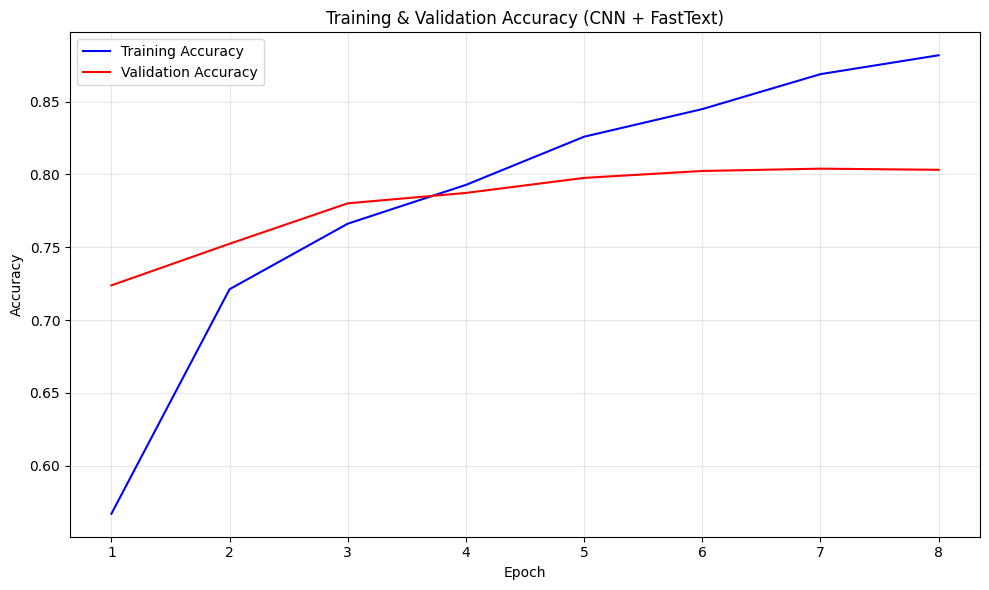

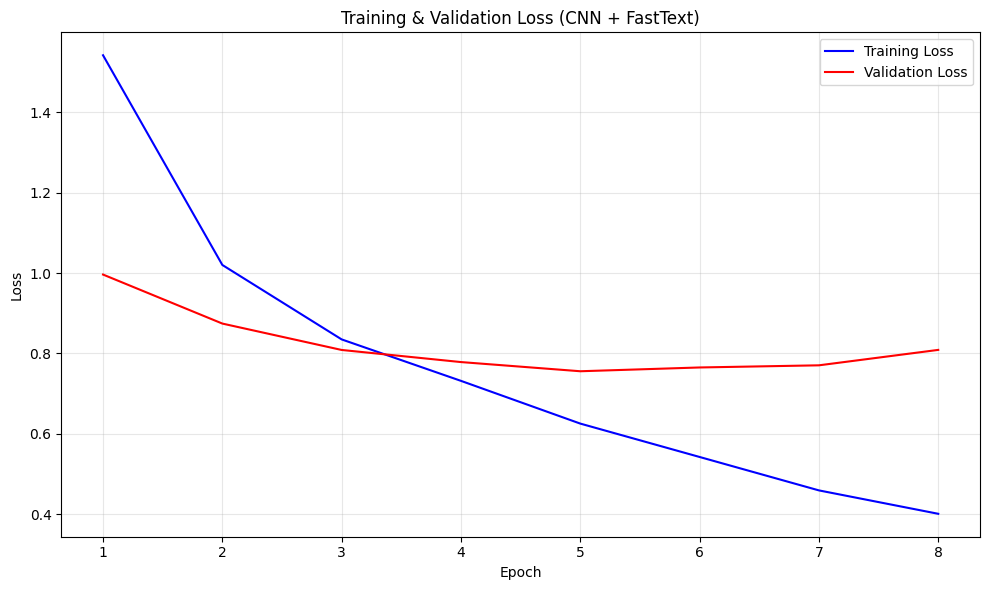

In [120]:
import matplotlib.pyplot as plt

# Extract training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# ------------------------------
# 1️⃣ Accuracy Curve
# ------------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy (CNN + FastText)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------
# 2️⃣ Loss Curve
# ------------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss (CNN + FastText)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


for the report

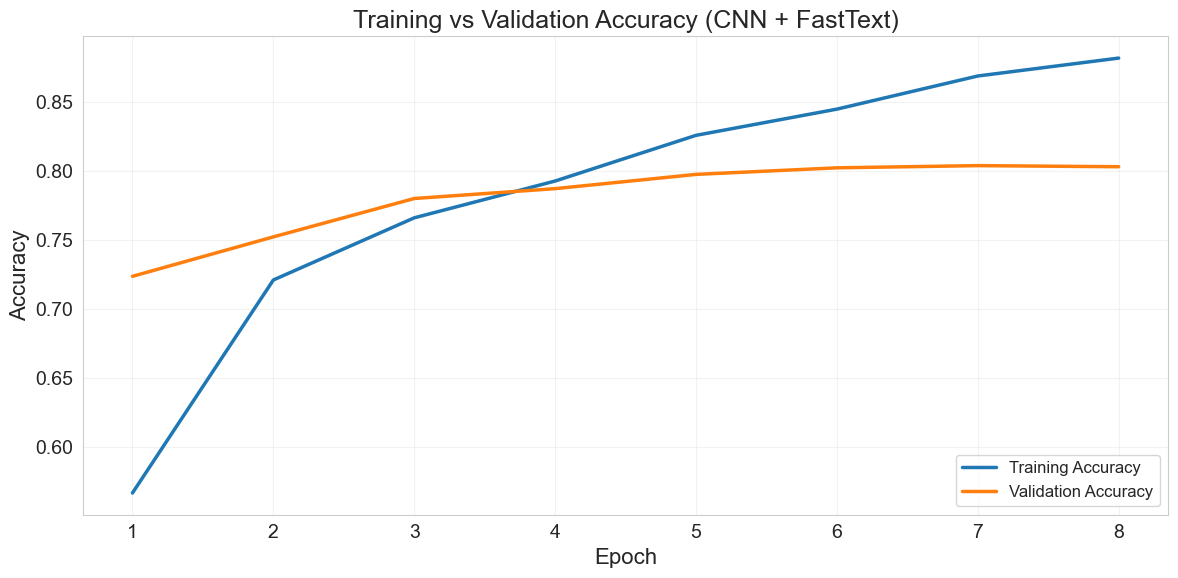

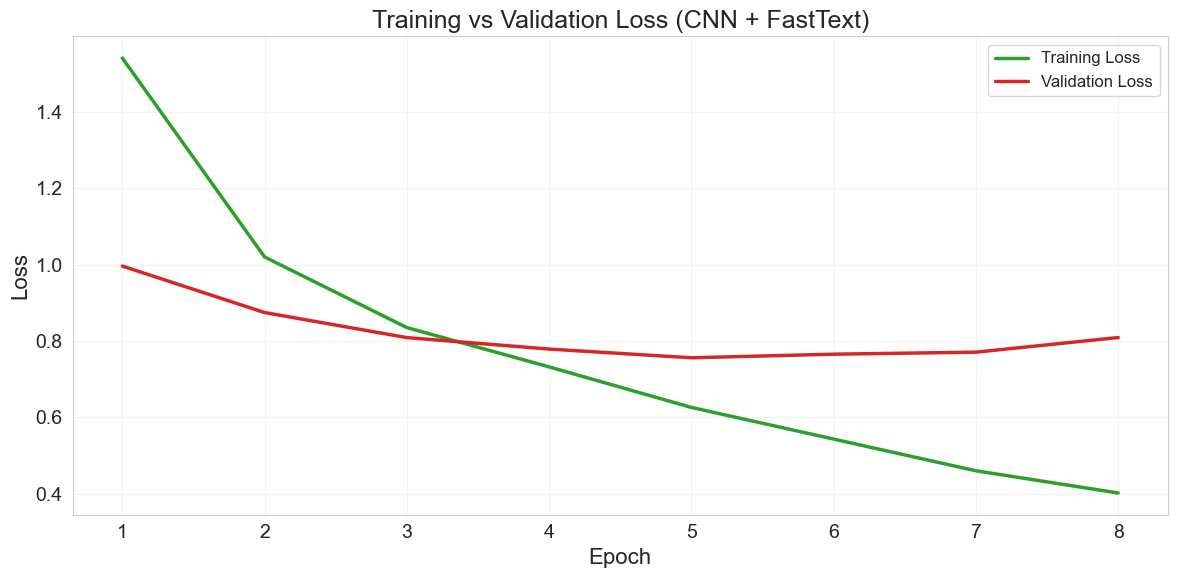

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use clean professional style
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "figure.figsize": (12, 6),
    "lines.linewidth": 2.5
})

# Extract training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# ============ PLOT 1: ACCURACY ================
plt.figure(figsize=(12, 6))
plt.plot(epochs, acc, label="Training Accuracy", color="#1f77b4")
plt.plot(epochs, val_acc, label="Validation Accuracy", color="#ff7f0e")

plt.title("Training vs Validation Accuracy (CNN + FastText)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ============ PLOT 2: LOSS ====================
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, label="Training Loss", color="#2ca02c")
plt.plot(epochs, val_loss, label="Validation Loss", color="#d62728")

plt.title("Training vs Validation Loss (CNN + FastText)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [116]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, pred_labels)

# Print raw matrix
print("\n=== FULL CONFUSION MATRIX (Raw Counts) ===\n")
print(cm)

# Optional: print with labels for readability
labels = le.classes_
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\n=== FULL CONFUSION MATRIX (with labels) ===\n")
print(cm_df)



=== FULL CONFUSION MATRIX (Raw Counts) ===

[[  7   0   5   3   1   1   0   0   0   1   1   3   0   0   0   4   0   0]
 [  0 111   0   2   0   1   0   0   0   0   0   1   0  14   0   0   0   2]
 [  1   0 225   3   2   3   3   0   1  11   6   1   0   1   0   1   0   6]
 [  1   0   3 223   4   3   2   0   0   2   0   0   1   4   0   1   0   7]
 [  2   0  10  25   4   3   2   1   0  11   0   2   0   5   0   3   0   9]
 [  0   0   3   7   3 372   2   1   4  13   0   0   2   2   0   1   0  16]
 [  0   0   9   1   5   1  18   1   0   1   1   1   1   3   0   3   0   6]
 [  0   0   0   3   0   0   0  64   0   9   0   0   0   2   0   1   0   7]
 [  0   0  19   1   0  13   1   0  64  19   2   0   1   0   0   1   0   7]
 [  0   0   4   2   1  12   0   1   3 224   0   0   0   0   0   0   0   5]
 [  0   0   6   1   0   0   0   0   0   0  35   0   0   0   0   0   0   1]
 [  1   0   2   1   0   1   0   0   0   0   0  42   0   0   0   5   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0 132  

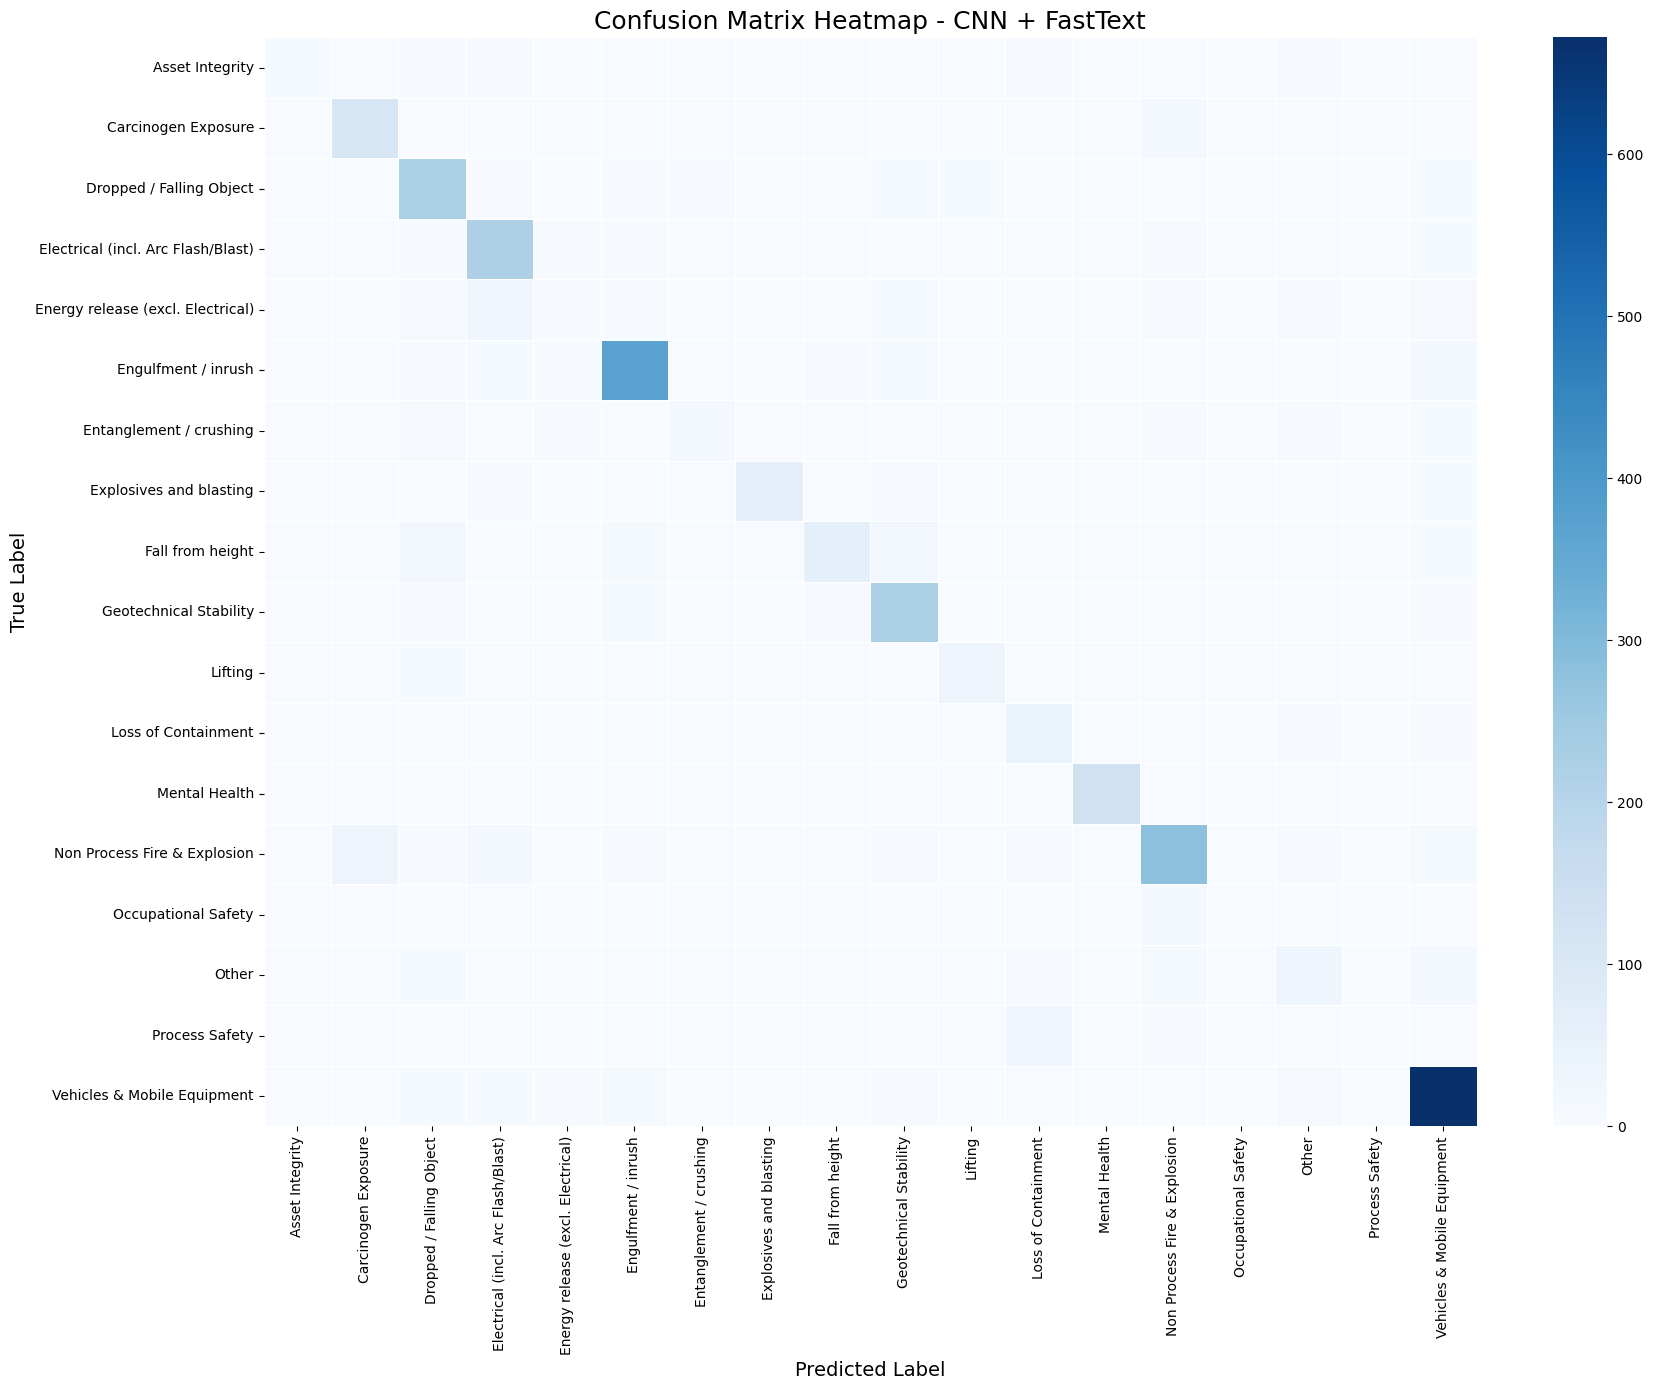

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, pred_labels)

# Create DataFrame with labels
labels = le.classes_
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(18, 14))
sns.heatmap(cm_df, annot=False, cmap="Blues", fmt="g",
            cbar=True, linewidths=.5)

plt.title("Confusion Matrix Heatmap - CNN + FastText", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


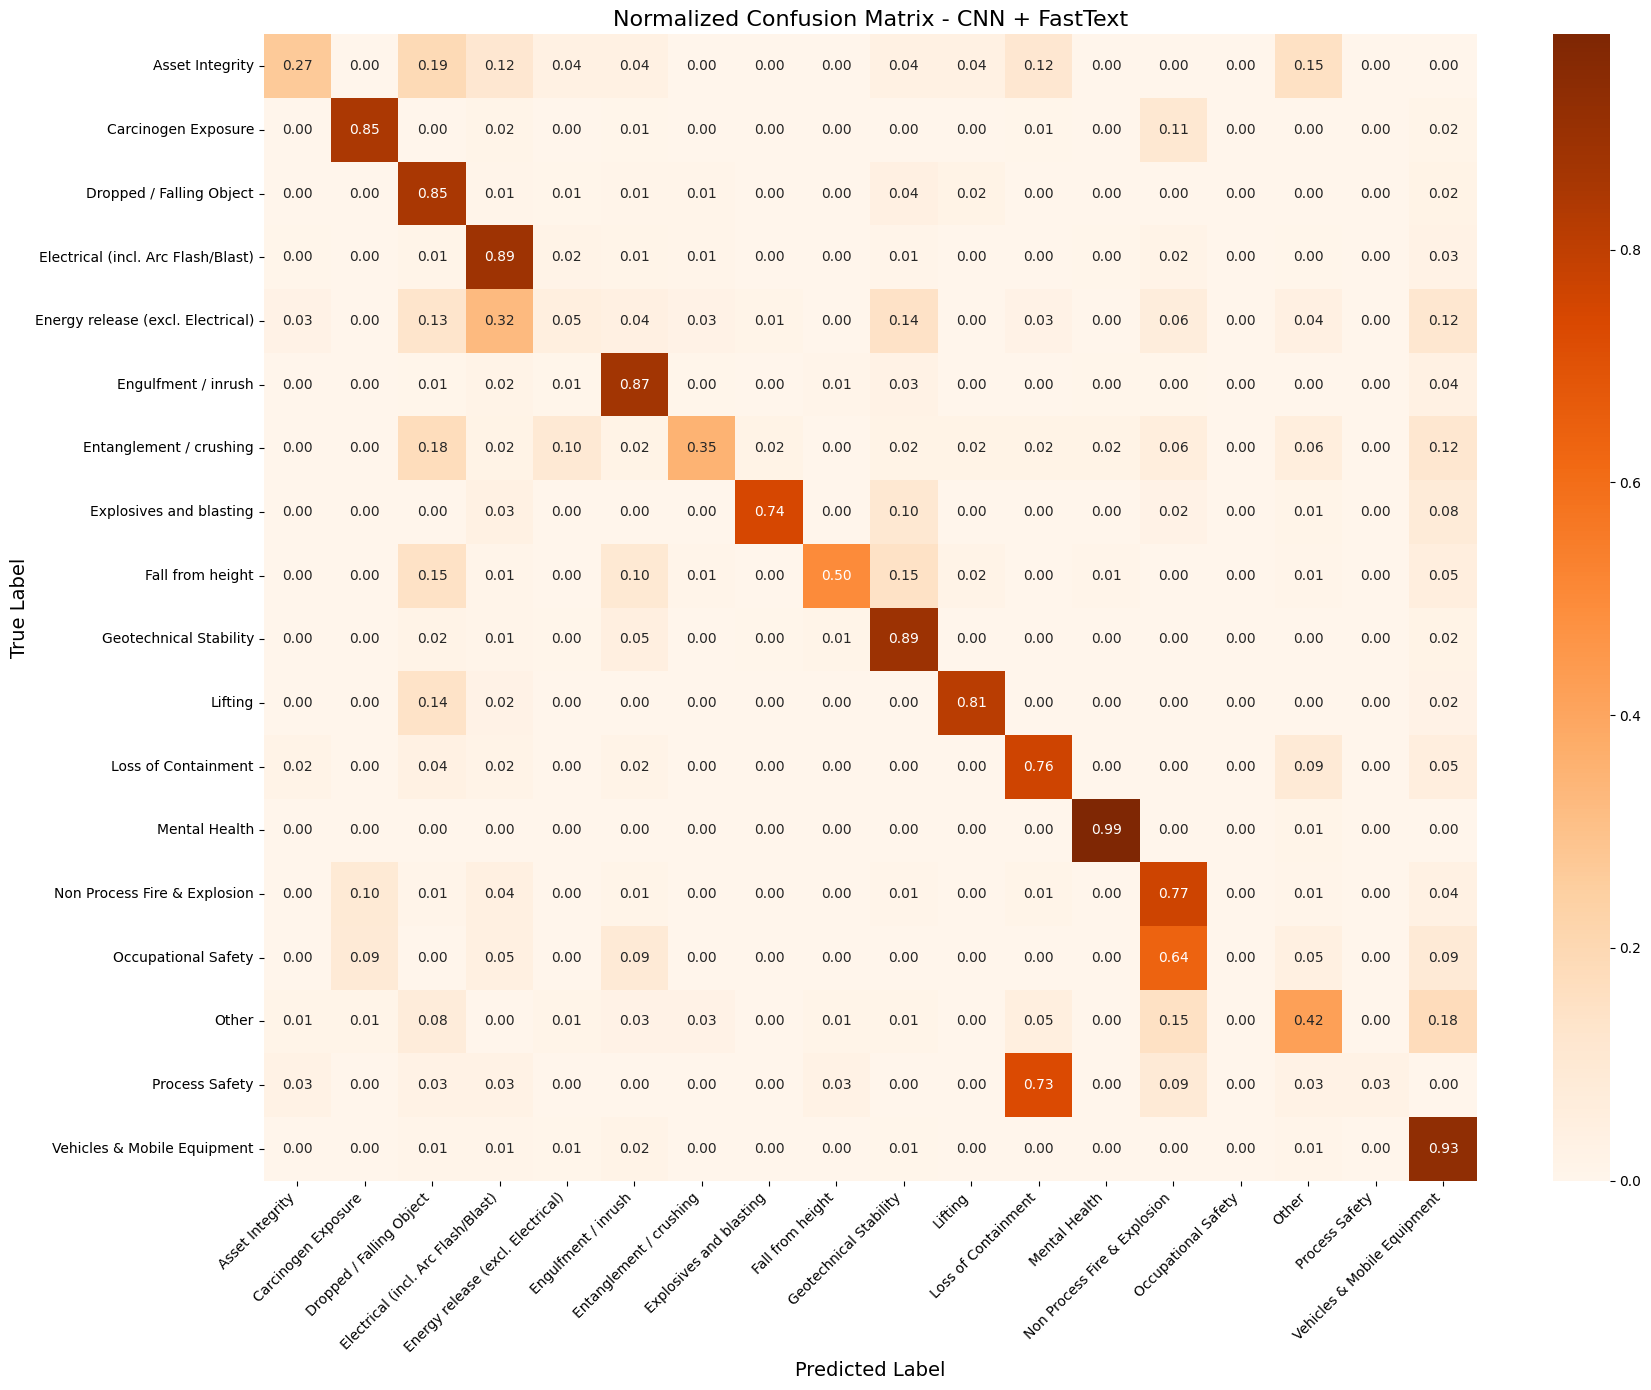

In [118]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 14))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=labels, yticklabels=labels)

plt.title("Normalized Confusion Matrix - CNN + FastText", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


                                      Count  Cumulative %
SAFETY_RISK_CATEGORY                                     
Vehicles & Mobile Equipment            3619     22.989455
Engulfment / inrush                    2128     36.507432
Non Process Fire & Explosion           1838     48.183204
Dropped / Falling Object               1318     56.555711
Geotechnical Stability                 1258     64.547072
Electrical (incl. Arc Flash/Blast)     1256     72.525727
Mental Health                           669     76.775505
Carcinogen Exposure                     653     80.923644
Fall from height                        641     84.995553
Explosives and blasting                 430     87.727099
Energy release (excl. Electrical)       385     90.172786
Loss of Containment                     273     91.907000
Entanglement / crushing                 256     93.533223
Lifting                                 216     94.905349
Process Safety                          168     95.972557
Asset Integrit

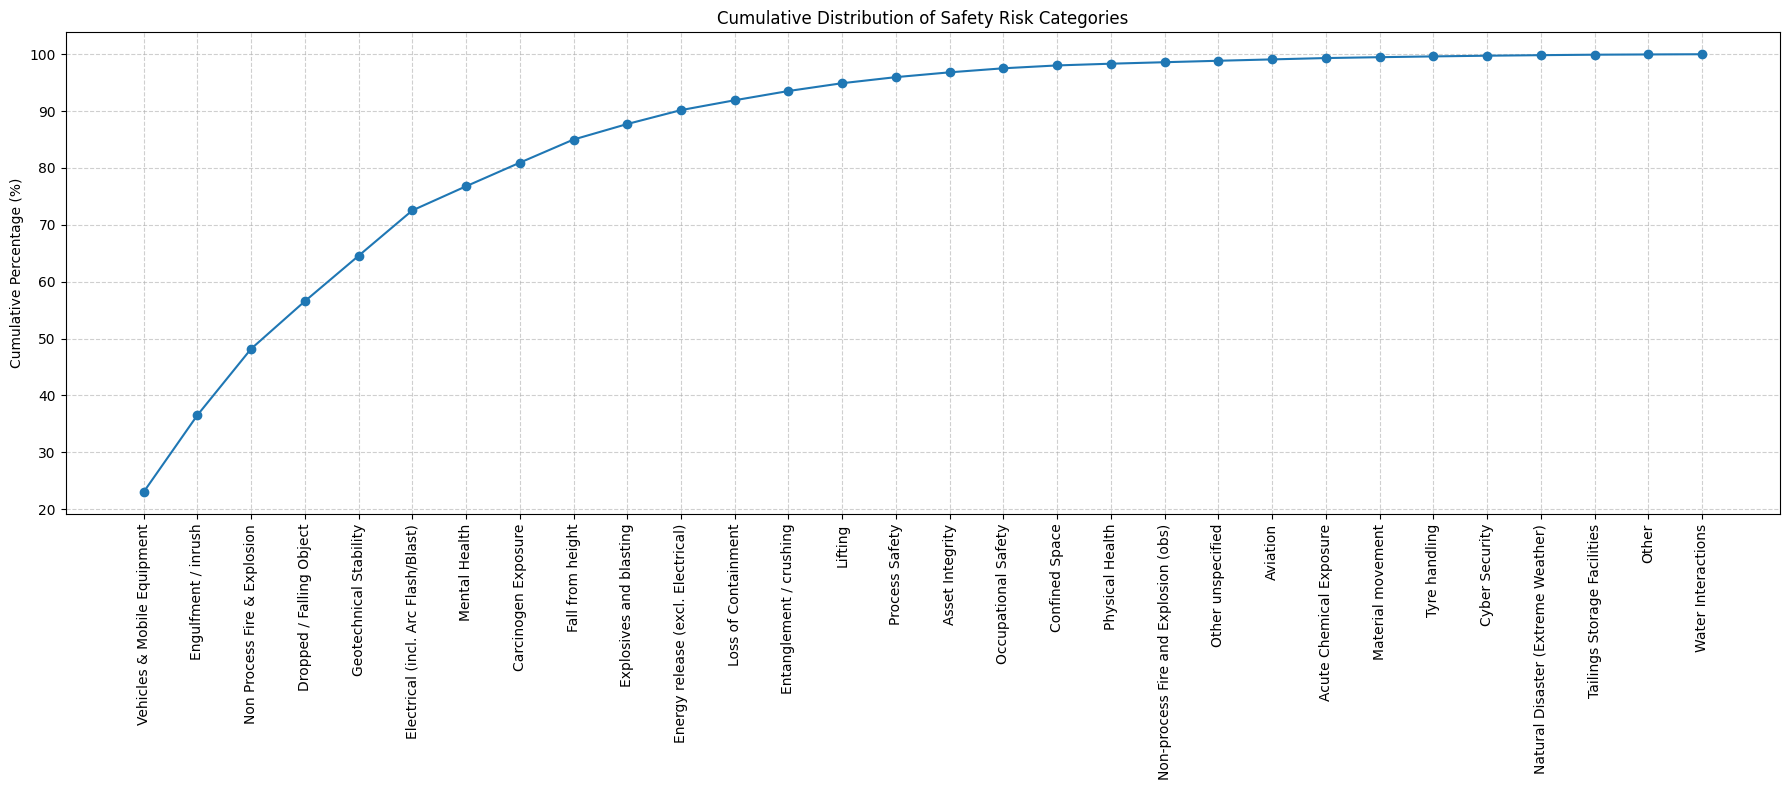

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Count category frequencies
# cat_counts = df["SAFETY_RISK_CATEGORY"].value_counts()

# # Compute cumulative %
# cumulative_percent = cat_counts.cumsum() / cat_counts.sum() * 100

# # Combined DataFrame for display
# cum_df = pd.DataFrame({
#     "Count": cat_counts,
#     "Cumulative %": cumulative_percent
# })

# print(cum_df)

# # Plot
# plt.figure(figsize=(18, 8))
# plt.plot(cumulative_percent.index, cumulative_percent.values, marker='o')
# plt.xticks(rotation=90)
# plt.ylabel("Cumulative Percentage (%)")
# plt.title("Cumulative Distribution of Safety Risk Categories")
# plt.grid(linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()


                                      Count  Cumulative %
Vehicles & Mobile Equipment            3619     22.989455
Engulfment / inrush                    2128     36.507432
Non Process Fire & Explosion           1838     48.183204
Dropped / Falling Object               1318     56.555711
Geotechnical Stability                 1258     64.547072
Electrical (incl. Arc Flash/Blast)     1256     72.525727
Mental Health                           669     76.775505
Carcinogen Exposure                     653     80.923644
Fall from height                        641     84.995553
Explosives and blasting                 430     87.727099
Energy release (excl. Electrical)       385     90.172786
Loss of Containment                     273     91.907000
Entanglement / crushing                 256     93.533223
Lifting                                 216     94.905349
Process Safety                          168     95.972557
Asset Integrity                         133     96.817431
Occupational S

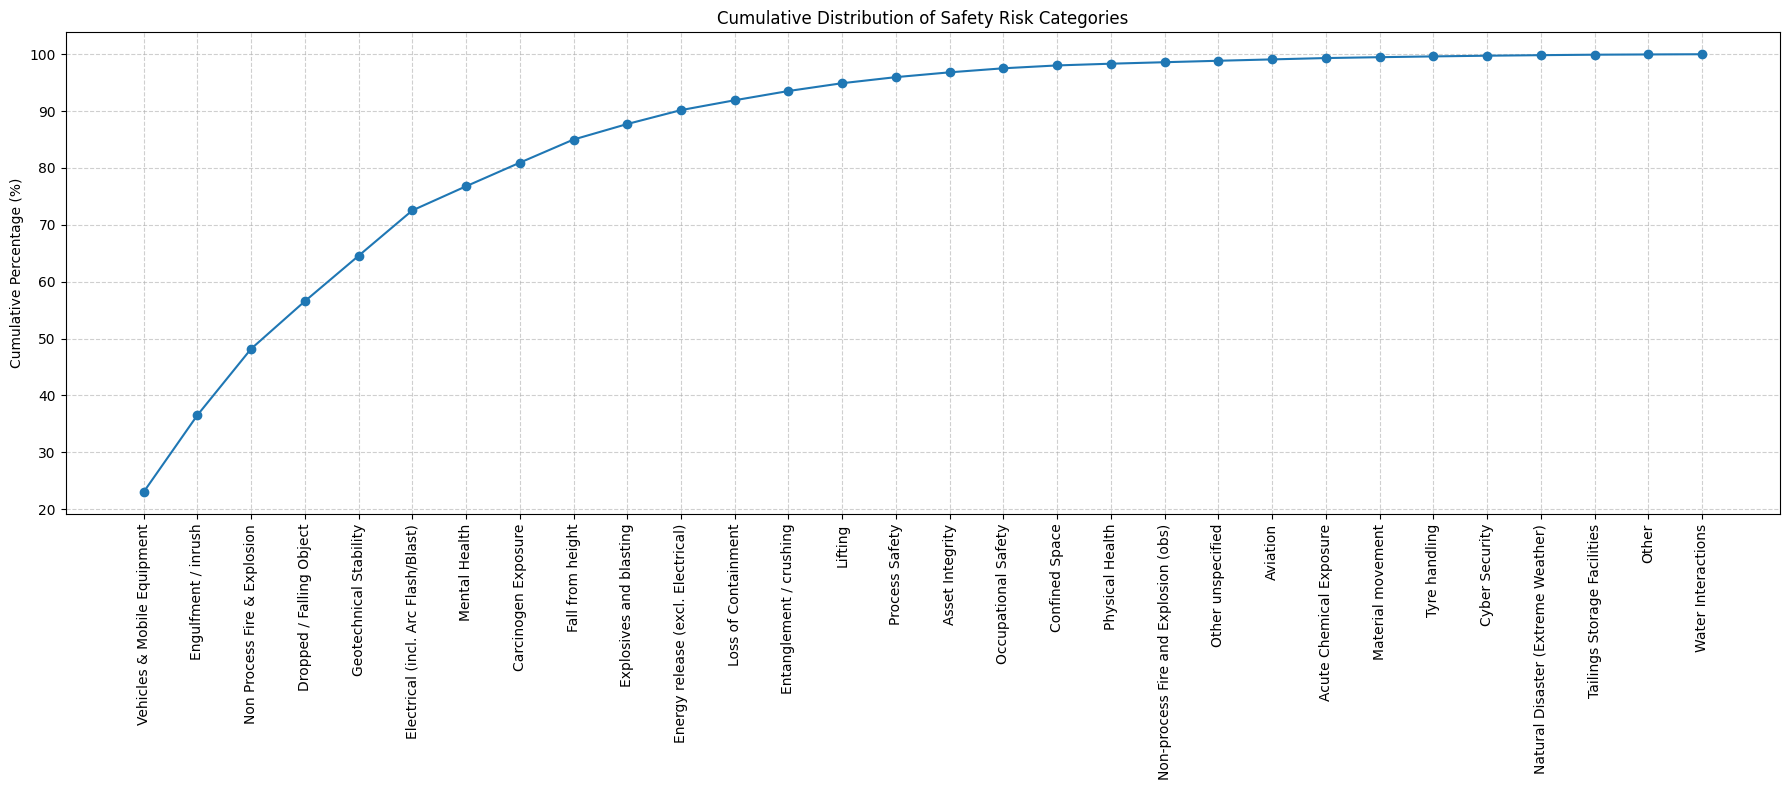

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Convert numeric labels to category names
# classes = le.classes_
# cat_series = pd.Series([classes[i] for i in y])

# # Count
# cat_counts = cat_series.value_counts()

# # Cumulative %
# cumulative_percent = cat_counts.cumsum() / cat_counts.sum() * 100

# # Create table
# cum_df = pd.DataFrame({
#     "Count": cat_counts,
#     "Cumulative %": cumulative_percent
# })

# print(cum_df)

# # Plot
# plt.figure(figsize=(18, 8))
# plt.plot(cumulative_percent.index, cumulative_percent.values, marker='o')
# plt.xticks(rotation=90)
# plt.ylabel("Cumulative Percentage (%)")
# plt.title("Cumulative Distribution of Safety Risk Categories")
# plt.grid(linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()


In [30]:
df = pd.read_excel(
    "C:/Study Materials/RA-ECU/Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [31]:
# Identify unlabeled rows
unlabeled_df = df[
    df["SAFETY_RISK_CATEGORY"].isna() |
    (df["SAFETY_RISK_CATEGORY"].astype(str).str.strip() == "")
]

# Identify labeled rows
labeled_df = df[
    df["SAFETY_RISK_CATEGORY"].notna() &
    (df["SAFETY_RISK_CATEGORY"].astype(str).str.strip() != "")
]


In [32]:
print("Total rows:", len(df))
print("Labeled rows:", len(labeled_df))
print("Unlabeled rows:", len(unlabeled_df))


Total rows: 87262
Labeled rows: 15742
Unlabeled rows: 71520


In [33]:
unlabeled_df[["WHAT_HAPPENED_ENGLISH", "SAFETY_RISK_CATEGORY"]].head(20)


,WHAT_HAPPENED_ENGLISH,SAFETY_RISK_CATEGORY
0,No access to a machine for preventative mainte...,NaN
1,During inspection of RB39 North it was found t...,NaN
2,SPFY25 - Identified forklift operating along r...,NaN
3,SPFY25 - During GEMBA walk identified a piece ...,NaN
4,Building unsecured after hours,NaN
5,Fan vent bag ripped down from level fan at 3L ...,NaN
6,Mine end fuel bay underwater / trip hazard,NaN
7,CCD 6 4421TK1541 E duct spool hole out on the ...,NaN
8,Found on Service DG057 that Seat Switch for pa...,NaN
9,"Pt was operating an IT when, they hit a pothol...",NaN


In [34]:
unlabeled_df.to_excel("unlabeled_masterdata.xlsx", index=False)


excel file for top3 categories for tf idf and CNN+fasttext

In [36]:
import pandas as pd
import numpy as np

# -------------------------------
# Load Master Data
# -------------------------------
df_master = pd.read_excel(
    "C:/Study Materials/RA-ECU/Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)

# Identify unlabeled rows
unlabeled_df = df_master[df_master["SAFETY_RISK_CATEGORY"].isna()].copy()
unlabeled_df = unlabeled_df.dropna(subset=["WHAT_HAPPENED_ENGLISH"])

print("Total Master Rows:", len(df_master))
print("Unlabeled Rows:", len(unlabeled_df))

# -------------------------------
# Clean Text (same function you used before)
# -------------------------------
unlabeled_df["clean_tokens"] = unlabeled_df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)
unlabeled_df["clean_text"] = unlabeled_df["clean_tokens"].apply(lambda x: " ".join(x))

# -------------------------------
# TF-IDF Vectorization
# -------------------------------
X_unlabeled_tfidf = vectorizer.transform(unlabeled_df["clean_text"])

# -------------------------------
# PREDICT TOP 3 CATEGORIES
# -------------------------------
probs = tfidf_clf.predict_proba(X_unlabeled_tfidf)

top3_indices = np.argsort(probs, axis=1)[:, -3:][:, ::-1]  # top 3, sorted highest→lowest
top3_categories = le.inverse_transform(top3_indices.flatten()).reshape(len(unlabeled_df), 3)
top3_conf = np.take_along_axis(probs, top3_indices, axis=1)

# -------------------------------
# Construct Final Minimal Output
# -------------------------------
unlabeled_output = pd.DataFrame({
    "WHAT_HAPPENED_ENGLISH": unlabeled_df["WHAT_HAPPENED_ENGLISH"].values,
    "clean_tokens": unlabeled_df["clean_tokens"].apply(lambda x: str(x)).values,
    "Top_3_Predicted_Categories": top3_categories.tolist(),
    "Top_3_Confidences": top3_conf.tolist()
})

# -------------------------------
# SAVE TO EXCEL
# -------------------------------
output_path = "TFIDF_Unlabeled_Predictions_Top3.xlsx"
unlabeled_output.to_excel(output_path, index=False)

print("Prediction file saved:", output_path)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Total Master Rows: 87262
Unlabeled Rows: 71517
Prediction file saved: TFIDF_Unlabeled_Predictions_Top3.xlsx


In [46]:
##  2. Convert Unlabeled Text Into FastText Embeddings

In [37]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================================================
# 1️⃣ Load ONLY "What happened" text
# =========================================================
df_master = pd.read_excel(
    r"C:/Study Materials/RA-ECU/Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)

unlabeled_df = df_master[['WHAT_HAPPENED_ENGLISH']].dropna()
unlabeled_df = unlabeled_df[unlabeled_df['WHAT_HAPPENED_ENGLISH'].str.strip() != ""]

print("Unlabeled rows:", len(unlabeled_df))

# =========================================================
# 2️⃣ Clean text (same function used in training)
# =========================================================
unlabeled_df["clean_tokens"] = unlabeled_df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)
unlabeled_texts = unlabeled_df["clean_tokens"].apply(lambda x: " ".join(x))

# =========================================================
# 3️⃣ Convert to padded sequences
# =========================================================
seqs = tokenizer.texts_to_sequences(unlabeled_texts)
padded = pad_sequences(seqs, maxlen=MAX_LEN)

print("Padded shape:", padded.shape)

# =========================================================
# 4️⃣ Predict using CNN + FastText
# =========================================================
probs = model.predict(padded, batch_size=128, verbose=1)

# Top-3 category indices per row
top3_idx = np.argsort(probs, axis=1)[:, -3:][:, ::-1]     # highest → lowest

# Top-3 confidence values
top3_conf = np.sort(probs, axis=1)[:, -3:][:, ::-1]

# Map indices to category names
top3_labels = np.array(le.classes_)[top3_idx]

# Convert lists into strings for Excel
unlabeled_df["Top_3_Categories"] = top3_labels.tolist()
unlabeled_df["Top_3_Confidences"] = top3_conf.tolist()

# =========================================================
# 5️⃣ Select ONLY four columns (client-ready)
# =========================================================
final_df = unlabeled_df[[
    "WHAT_HAPPENED_ENGLISH",
    "clean_tokens",
    "Top_3_Categories",
    "Top_3_Confidences"
]]

# =========================================================
# 6️⃣ Save to Excel
# =========================================================
output_path = "Unlabeled_Predictions_CNN_FastText.xlsx"
final_df.to_excel(output_path, index=False)

print("\nCNN+FastText Excel saved at:", output_path)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Unlabeled rows: 87259
Padded shape: (87259, 100)
682/682 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step

CNN+FastText Excel saved at: Unlabeled_Predictions_CNN_FastText.xlsx


In [85]:
# ============================================
# 0. Imports
# ============================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import FastText

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# If you haven't downloaded these before, run once:
# nltk.download("punkt")
# nltk.download("stopwords")
# nltk.download("wordnet")

# For reproducibility (optional)
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

# ============================================
# 1. Load Data
# ============================================
path = r"C:/Study Materials/RA-ECU/Events Inc. What Happened_Example data.xlsx"
df = pd.read_excel(path, sheet_name="MasterData")

# Keep only necessary columns and drop NA
df = df[["WHAT_HAPPENED_ENGLISH", "SAFETY_RISK_CATEGORY"]].dropna()
print("Rows after dropping NA:", len(df))

# ============================================
# 2. Text Cleaning
# ============================================
stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def clean_text(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]           # keep only words
    tokens = [t for t in tokens if t not in stop_words]   # remove stopwords
    tokens = [lemm.lemmatize(t) for t in tokens]          # lemmatise
    return tokens

df["clean_tokens"] = df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)

# ============================================
# 3. Merge Rare Classes (threshold < 30)
# ============================================
counts = df["SAFETY_RISK_CATEGORY"].value_counts()
rare_classes = counts[counts < 30].index.tolist()
print("Number of original classes:", len(counts))
print("Rare classes (<30):", len(rare_classes))

df["SAFETY_RISK_CATEGORY"] = df["SAFETY_RISK_CATEGORY"].apply(
    lambda x: "Other" if x in rare_classes else x
)

print("\nClass distribution AFTER merging rare classes:")
print(df["SAFETY_RISK_CATEGORY"].value_counts())

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["SAFETY_RISK_CATEGORY"])
num_classes = len(le.classes_)
print("\nNumber of final classes:", num_classes)

# ============================================
# 4. Train / Test Split
# ============================================
X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    df["clean_tokens"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("\nTrain size:", len(X_train_tokens), " Test size:", len(X_test_tokens))

# ============================================
# 5. Train FastText (vector_size = 100)
# ============================================
fasttext_model = FastText(
    sentences=df["clean_tokens"],
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,         # skip-gram
    workers=4,
    epochs=10
)
print("\nFastText trained.")

# ============================================
# 6. Tokeniser & Sequences for CNN
# ============================================
MAX_WORDS = 20000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_tokens"].apply(lambda x: " ".join(x)))

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index)) + 1

def tokens_to_padded(tokens_series):
    texts = tokens_series.apply(lambda x: " ".join(x))
    seq = tokenizer.texts_to_sequences(texts)
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    return pad

X_train_pad = tokens_to_padded(X_train_tokens)
X_test_pad = tokens_to_padded(X_test_tokens)

print("\nPadded shapes -> train:", X_train_pad.shape, " test:", X_test_pad.shape)

# ============================================
# 7. Build FastText Embedding Matrix (dim=100)
# ============================================
embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in fasttext_model.wv:
        embedding_matrix[i] = fasttext_model.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

print("Embedding matrix shape:", embedding_matrix.shape)

# One-hot labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ============================================
# 8. Compute Class Weights (for imbalance)
# ============================================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("\nClass weights:", class_weights)

# ============================================
# 9. CNN + FastText MODEL (simpler, non-trainable embedding)
# ============================================
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False          # DO NOT fine-tune FastText on this dataset
    ),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_LEN))
print("\nCNN + FastText Model Summary:")
model.summary()

# ============================================
# 10. Train with EarlyStopping
# ============================================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

# ============================================
# 11. Evaluation
# ============================================
pred_probs = model.predict(X_test_pad, batch_size=128)
pred_labels = np.argmax(pred_probs, axis=1)

print("\n=== FINAL CNN + FastText Classification Report ===\n")
print(classification_report(y_test, pred_labels, target_names=le.classes_))

cnn_ft_accuracy = accuracy_score(y_test, pred_labels)
print("Final CNN + FastText Accuracy:", cnn_ft_accuracy)


C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Rows after dropping NA: 15742
Number of original classes: 33
Rare classes (<30): 10

Class distribution AFTER merging rare classes:
SAFETY_RISK_CATEGORY
Vehicles & Mobile Equipment             3619
Engulfment / inrush                     2128
Non Process Fire & Explosion            1838
Dropped / Falling Object                1318
Geotechnical Stability                  1258
Electrical (incl. Arc Flash/Blast)      1256
Mental Health                            669
Carcinogen Exposure                      653
Fall from height                         641
Explosives and blasting                  430
Energy release (excl. Electrical)        385
Loss of Containment                      273
Entanglement / crushing                  256
Lifting                                  216
Process Safety                           168
Asset Integrity                          133
Occupational Safety                      112
Other                                    106
Confined Space                       

C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



CNN + FastText Model Summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 100, 100)       │       891,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_9          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 965,144 (3.68 MB)

 Trainable params: 73,944 (288.84 KB)

 Non-trainable params: 891,200 (3.40 MB)

Epoch 1/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.2954 - loss: 2.7657 - val_accuracy: 0.5762 - val_loss: 1.8196
Epoch 2/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.4875 - loss: 2.0976 - val_accuracy: 0.6103 - val_loss: 1.4859
Epoch 3/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5462 - loss: 1.7531 - val_accuracy: 0.6246 - val_loss: 1.3884
Epoch 4/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5818 - loss: 1.5231 - val_accuracy: 0.6349 - val_loss: 1.3631
Epoch 5/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6048 - loss: 1.3868 - val_accuracy: 0.6571 - val_loss: 1.2522
Epoch 6/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.6235 - loss: 1.2067 - val_accuracy: 0.6706 - val_loss: 1.1933
Epoch 7/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6387 - loss: 1.0978 - val_accuracy: 0.6667 - val_loss: 1.1461
Epoch 8/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6527 - loss: 1.0260 - val

## Removing rare class and run

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

# =========================
# Data Loading
# =========================
df = pd.read_excel(
    r"C:\Study Materials\RA-ECU\Events Inc. What Happened_Example data.xlsx",
    sheet_name="MasterData"
)

df = df[["WHAT_HAPPENED_ENGLISH", "SAFETY_RISK_CATEGORY"]].dropna().copy()

print("Original shape:", df.shape)
print("Original class count:", df["SAFETY_RISK_CATEGORY"].nunique())

# =========================
# Text Cleaning
# =========================
stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def clean_text(text):
    tokens = nltk.word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemm.lemmatize(t) for t in tokens]
    return tokens

df["clean_tokens"] = df["WHAT_HAPPENED_ENGLISH"].apply(clean_text)
df["clean_text"] = df["clean_tokens"].apply(lambda x: " ".join(x))

# =========================
# Remove Rare Classes
# Keep labels with >= 41 samples
# =========================
MIN_SAMPLES = 41

category_counts = df["SAFETY_RISK_CATEGORY"].value_counts()

kept_classes = category_counts[category_counts >= MIN_SAMPLES].index.tolist()
removed_classes = category_counts[category_counts < MIN_SAMPLES].index.tolist()

print("\nClasses to KEEP:")
print(kept_classes)

print("\nClasses to REMOVE:")
print(removed_classes)

df_filtered = df[df["SAFETY_RISK_CATEGORY"].isin(kept_classes)].copy()

print("\nFiltered shape:", df_filtered.shape)
print("Remaining classes:", df_filtered["SAFETY_RISK_CATEGORY"].nunique())
print(df_filtered["SAFETY_RISK_CATEGORY"].value_counts())

# =========================
# Encode final labels
# =========================
le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["SAFETY_RISK_CATEGORY"])

print("\nLabel mapping:")
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mohaj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
C:\Users\mohaj\AppData\Roaming\Python\Python310\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Original shape: (15742, 2)
Original class count: 33

Classes to KEEP:
['Vehicles & Mobile Equipment', 'Engulfment / inrush', 'Non Process Fire & Explosion', 'Dropped / Falling Object', 'Geotechnical Stability', 'Electrical (incl. Arc Flash/Blast)', 'Mental Health', 'Carcinogen Exposure', 'Fall from height', 'Explosives and blasting', 'Energy release (excl. Electrical)', 'Loss of Containment', 'Entanglement / crushing', 'Lifting', 'Process Safety', 'Asset Integrity', 'Occupational Safety', 'Confined Space', 'Physical Health', 'Non-process Fire and Explosion (obs)']

Classes to REMOVE:
['Other unspecified', 'Aviation', 'Acute Chemical Exposure', 'Material movement', 'Tyre handling', 'Cyber Security', 'Natural Disaster (Extreme Weather)', 'Tailings Storage Facilities', 'Water Interactions', 'Emergency Preparedness', 'Community', 'Planning & Technical', 'Emergency Response']

Filtered shape: (15521, 4)
Remaining classes: 20
SAFETY_RISK_CATEGORY
Vehicles & Mobile Equipment             3619


In [2]:
# =========================
# Train Word2Vec
# =========================
sentences = df_filtered["clean_tokens"].tolist()

w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,          # skip-gram
    workers=4,
    epochs=10
)

# =========================
# Convert Sentences -> Document Embeddings
# =========================
def doc_vector(tokens):
    tokens = [t for t in tokens if t in w2v.wv]
    if len(tokens) == 0:
        return np.zeros(100)
    return np.mean(w2v.wv[tokens], axis=0)

X_vectors = np.vstack(df_filtered["clean_tokens"].apply(doc_vector).values)
y = df_filtered["label"].values

print("Word2Vec feature shape:", X_vectors.shape)
print("Target shape:", y.shape)

Word2Vec feature shape: (15521, 100)
Target shape: (15521,)


In [3]:
# =========================
# Split data for Word2Vec
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# =========================
# Train Word2Vec + Logistic Regression
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

clf_w2v = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

clf_w2v.fit(X_train, y_train)

preds_w2v = clf_w2v.predict(X_test)

print("\n=== Word2Vec Classification Report ===\n")
print(classification_report(y_test, preds_w2v, target_names=le.classes_))

w2v_accuracy = accuracy_score(y_test, preds_w2v)
w2v_macro_f1 = f1_score(y_test, preds_w2v, average="macro")
w2v_weighted_f1 = f1_score(y_test, preds_w2v, average="weighted")

print("Word2Vec Accuracy:", w2v_accuracy)
print("Word2Vec Macro F1:", w2v_macro_f1)
print("Word2Vec Weighted F1:", w2v_weighted_f1)


=== Word2Vec Classification Report ===

                                      precision    recall  f1-score   support

                     Asset Integrity       0.25      0.62      0.36        26
                 Carcinogen Exposure       0.77      0.85      0.81       131
                      Confined Space       0.50      0.88      0.64        16
            Dropped / Falling Object       0.82      0.66      0.73       264
  Electrical (incl. Arc Flash/Blast)       0.80      0.77      0.79       251
   Energy release (excl. Electrical)       0.11      0.14      0.12        77
                 Engulfment / inrush       0.88      0.79      0.83       426
             Entanglement / crushing       0.30      0.65      0.41        51
             Explosives and blasting       0.68      0.74      0.71        86
                    Fall from height       0.52      0.66      0.58       128
              Geotechnical Stability       0.78      0.76      0.77       252
                      

In [ ]:
# =========================
# TF-IDF (1,5 gram) + Logistic Regression
# =========================
from sklearn.svm import LinearSVC
print("Running TF-IDF (1-5 grams)...")

texts = df_filtered["clean_text"]
labels = df_filtered["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(
    ngram_range=(1,5),   # unigrams + bigrams
    max_features=15000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("TF-IDF shape:", X_train_tfidf.shape)

# tfidf_clf = LogisticRegression(
#     max_iter=4000,
#     #class_weight="balanced",
#     random_state=42
# )

# tfidf_clf.fit(X_train_tfidf, y_train)

# preds_tfidf = tfidf_clf.predict(X_test_tfidf)

svm_clf = LinearSVC()

svm_clf.fit(X_train_tfidf, y_train)

preds = svm_clf.predict(X_test_tfidf)

print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))

acc = accuracy_score(y_test, preds)
macro = f1_score(y_test, preds, average="macro")
weighted = f1_score(y_test, preds, average="weighted")

print("LinearSVC Accuracy:", acc)
print("Macro F1:", macro)
print("Weighted F1:", weighted)


# print("\n=== TF-IDF (1,2 gram) Classification Report ===\n")
# print(classification_report(y_test, preds_tfidf, target_names=le.classes_))

# tfidf_accuracy = accuracy_score(y_test, preds_tfidf)
# tfidf_macro_f1 = f1_score(y_test, preds_tfidf, average="macro")
# tfidf_weighted_f1 = f1_score(y_test, preds_tfidf, average="weighted")

# print("TF-IDF Accuracy:", tfidf_accuracy)
# print("TF-IDF Macro F1:", tfidf_macro_f1)
# print("TF-IDF Weighted F1:", tfidf_weighted_f1)

Running TF-IDF (1-2 grams)...
TF-IDF shape: (12416, 15000)
                                      precision    recall  f1-score   support

                     Asset Integrity       0.83      0.38      0.53        26
                 Carcinogen Exposure       0.84      0.85      0.85       131
                      Confined Space       0.93      0.81      0.87        16
            Dropped / Falling Object       0.80      0.84      0.82       264
  Electrical (incl. Arc Flash/Blast)       0.78      0.88      0.83       251
   Energy release (excl. Electrical)       0.33      0.16      0.21        77
                 Engulfment / inrush       0.88      0.88      0.88       426
             Entanglement / crushing       0.60      0.53      0.56        51
             Explosives and blasting       0.94      0.85      0.89        86
                    Fall from height       0.72      0.63      0.67       128
              Geotechnical Stability       0.81      0.86      0.83       252
    

In [6]:
from gensim.models import FastText
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# Train FastText model
# =========================
fasttext_model = FastText(
    sentences=df_filtered["clean_tokens"].tolist(),
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,        # Skip-gram
    workers=4,
    epochs=15
)

print("FastText model trained.")

# =========================
# Sentence vector (mean embedding)
# =========================
def get_ft_vector(tokens):
    vectors = [fasttext_model.wv[t] for t in tokens if t in fasttext_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_ft = np.vstack(df_filtered["clean_tokens"].apply(get_ft_vector).values)
y_ft = df_filtered["label"].values

print("FastText vectors created:", X_ft.shape)

# =========================
# Train / test split
# =========================
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_ft,
    y_ft,
    test_size=0.2,
    random_state=42,
    stratify=y_ft
)

# =========================
# Train classifier
# =========================
clf_ft = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    random_state=42
)

clf_ft.fit(X_train_ft, y_train_ft)

# =========================
# Evaluate
# =========================
y_pred_ft = clf_ft.predict(X_test_ft)

print("\n=== FastText Classification Report ===\n")
print(classification_report(y_test_ft, y_pred_ft, target_names=le.classes_, zero_division=0))

ft_accuracy = accuracy_score(y_test_ft, y_pred_ft)
ft_macro_f1 = f1_score(y_test_ft, y_pred_ft, average="macro")
ft_weighted_f1 = f1_score(y_test_ft, y_pred_ft, average="weighted")

print("FastText Accuracy:", ft_accuracy)
print("FastText Macro F1:", ft_macro_f1)
print("FastText Weighted F1:", ft_weighted_f1)

FastText model trained.
FastText vectors created: (15521, 100)

=== FastText Classification Report ===

                                      precision    recall  f1-score   support

                     Asset Integrity       0.28      0.65      0.40        26
                 Carcinogen Exposure       0.75      0.85      0.80       131
                      Confined Space       0.43      0.81      0.57        16
            Dropped / Falling Object       0.84      0.68      0.75       264
  Electrical (incl. Arc Flash/Blast)       0.78      0.75      0.76       251
   Energy release (excl. Electrical)       0.18      0.26      0.21        77
                 Engulfment / inrush       0.90      0.81      0.85       426
             Entanglement / crushing       0.33      0.67      0.44        51
             Explosives and blasting       0.70      0.81      0.75        86
                    Fall from height       0.57      0.70      0.63       128
              Geotechnical Stability 

In [7]:
# ============================================
# FastText + CNN (Improved, cleaner version)
# Assumes df_filtered and le already exist
# ============================================

import numpy as np
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import FastText

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, Concatenate, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ============================================
# Reproducibility
# ============================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# 1. Train / Validation / Test Split
# ============================================
X = df_filtered["clean_tokens"]
y = df_filtered["label"]

X_train_tokens, X_test_tokens, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_train_tokens, X_val_tokens, y_train, y_val = train_test_split(
    X_train_tokens,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

print("Train size:", len(X_train_tokens))
print("Validation size:", len(X_val_tokens))
print("Test size:", len(X_test_tokens))

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

# ============================================
# 2. Train FastText ONLY on training tokens
# ============================================
fasttext_model = FastText(
    sentences=X_train_tokens.tolist(),
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,          # skip-gram
    workers=4,
    epochs=20
)

print("FastText trained.")
print("FastText vocab size:", len(fasttext_model.wv))

# ============================================
# 3. Tokenizer fit ONLY on training text
# ============================================
MAX_WORDS = 20000
MAX_LEN = 120
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_tokens.apply(lambda x: " ".join(x)))

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Tokenizer vocab size:", vocab_size)

# Convert token lists to strings first
X_train_text = X_train_tokens.apply(lambda x: " ".join(x))
X_val_text = X_val_tokens.apply(lambda x: " ".join(x))
X_test_text = X_test_tokens.apply(lambda x: " ".join(x))

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train padded shape:", X_train_pad.shape)
print("Val padded shape:", X_val_pad.shape)
print("Test padded shape:", X_test_pad.shape)

# ============================================
# 4. Build FastText Embedding Matrix
# ============================================
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype="float32")

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in fasttext_model.wv:
        embedding_matrix[i] = fasttext_model.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.2, size=(EMBED_DIM,))

print("Embedding matrix shape:", embedding_matrix.shape)

# ============================================
# 5. Compute class weights
# ============================================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: w for i, w in zip(np.unique(y_train), class_weights_array)}
print("Class weights:", class_weights)

# ============================================
# 6. Build Improved CNN Model
# Multi-kernel CNN for phrase lengths 3, 4, 5
# ============================================
input_layer = Input(shape=(MAX_LEN,))

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=EMBED_DIM,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

x = SpatialDropout1D(0.3)(embedding_layer)

conv_3 = Conv1D(128, 3, activation="relu")(x)
conv_4 = Conv1D(128, 4, activation="relu")(x)
conv_5 = Conv1D(128, 5, activation="relu")(x)

pool_3 = GlobalMaxPooling1D()(conv_3)
pool_4 = GlobalMaxPooling1D()(conv_4)
pool_5 = GlobalMaxPooling1D()(conv_5)

merged = Concatenate()([pool_3, pool_4, pool_5])

dense = Dense(128, activation="relu")(merged)
dense = Dropout(0.4)(dense)
dense = Dense(64, activation="relu")(dense)
dense = Dropout(0.3)(dense)

output_layer = Dense(num_classes, activation="softmax")(dense)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

print("\nImproved FastText + CNN Model Summary:")
model.summary()

# ============================================
# 7. Callbacks
# ============================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# ============================================
# 8. Train Model
# ============================================
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ============================================
# 9. Evaluate
# ============================================
pred_probs = model.predict(X_test_pad)
pred_labels = np.argmax(pred_probs, axis=1)

print("\n=== Improved FastText + CNN Classification Report ===\n")
print(classification_report(y_test, pred_labels, target_names=le.classes_, zero_division=0))

cnn_ft_accuracy = accuracy_score(y_test, pred_labels)
cnn_ft_macro_f1 = f1_score(y_test, pred_labels, average="macro")
cnn_ft_weighted_f1 = f1_score(y_test, pred_labels, average="weighted")

print("Improved FastText + CNN Accuracy:", cnn_ft_accuracy)
print("Improved FastText + CNN Macro F1:", cnn_ft_macro_f1)
print("Improved FastText + CNN Weighted F1:", cnn_ft_weighted_f1)

Train size: 11174
Validation size: 1242
Test size: 3105
Number of classes: 20
FastText trained.
FastText vocab size: 7645
Tokenizer vocab size: 7647
Train padded shape: (11174, 120)
Val padded shape: (1242, 120)
Test padded shape: (3105, 120)
Embedding matrix shape: (7647, 100)
Class weights: {np.int64(0): np.float64(5.819791666666666), np.int64(1): np.float64(1.1887234042553192), np.int64(2): np.float64(9.801754385964912), np.int64(3): np.float64(0.5887249736564805), np.int64(4): np.float64(0.6180309734513274), np.int64(5): np.float64(2.0169675090252706), np.int64(6): np.float64(0.36468668407310706), np.int64(7): np.float64(3.036413043478261), np.int64(8): np.float64(1.802258064516129), np.int64(9): np.float64(1.2093073593073593), np.int64(10): np.float64(0.6173480662983425), np.int64(11): np.float64(3.5814102564102566), np.int64(12): np.float64(2.850510204081633), np.int64(13): np.float64(1.1615384615384616), np.int64(14): np.float64(0.4222978080120937), np.int64(15): np.float64(18.6

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 120, 100)  │    764,700 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 120, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 118, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 117, 128)  │     51,328 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 116, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20)        │      1,300 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 977,520 (3.73 MB)

 Trainable params: 977,520 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.1394 - loss: 2.8404 - val_accuracy: 0.3406 - val_loss: 2.3622 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.3514 - loss: 2.2808 - val_accuracy: 0.6023 - val_loss: 1.6278 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.4986 - loss: 1.8900 - val_accuracy: 0.6329 - val_loss: 1.3916 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.5630 - loss: 1.6376 - val_accuracy: 0.6828 - val_loss: 1.1070 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - accuracy: 0.6048 - loss: 1.4279 - val_accuracy: 0.6908 - val_loss: 1.0976 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.6333 - loss: 1.2555 - val_accuracy: 0.7279 - val_loss: 0.9574 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.6611 - l

In [10]:
import os
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# create output folder
output_dir = "results/classification_reports"
os.makedirs(output_dir, exist_ok=True)

def save_report_and_metrics(y_true, y_pred, label_encoder, model_name, output_dir):
    # classification report
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose().round(4)
    report_path = os.path.join(output_dir, f"{model_name}_classification_report.csv")
    report_df.to_csv(report_path, index=True)

    # summary metrics
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    metrics_df = pd.DataFrame([{
        "model": model_name,
        "accuracy": round(acc, 4),
        "macro_precision": round(macro_p, 4),
        "macro_recall": round(macro_r, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_precision": round(weighted_p, 4),
        "weighted_recall": round(weighted_r, 4),
        "weighted_f1": round(weighted_f1, 4),
    }])

    metrics_path = os.path.join(output_dir, f"{model_name}_metrics.csv")
    metrics_df.to_csv(metrics_path, index=False)

    print(f"Saved: {report_path}")
    print(f"Saved: {metrics_path}")

# 1) TF-IDF
save_report_and_metrics(
    y_test,
    preds,
    le,
    "tfidf",
    output_dir
)

# 2) Word2Vec
save_report_and_metrics(
    y_test,
    preds_w2v,
    le,
    "word2vec",
    output_dir
)

# 3) FastText
save_report_and_metrics(
    y_test_ft,
    y_pred_ft,
    le,
    "fasttext",
    output_dir
)

# 4) FastText + CNN
save_report_and_metrics(
    y_test,
    pred_labels,
    le,
    "fasttext_cnn",
    output_dir
)

Saved: results/classification_reports\tfidf_classification_report.csv
Saved: results/classification_reports\tfidf_metrics.csv
Saved: results/classification_reports\word2vec_classification_report.csv
Saved: results/classification_reports\word2vec_metrics.csv
Saved: results/classification_reports\fasttext_classification_report.csv
Saved: results/classification_reports\fasttext_metrics.csv
Saved: results/classification_reports\fasttext_cnn_classification_report.csv
Saved: results/classification_reports\fasttext_cnn_metrics.csv


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# PATHS
# =========================================================
BASE_DIR = r"results/classification_reports"
PLOT_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(PLOT_DIR, exist_ok=True)

# =========================================================
# FILE PATHS
# =========================================================
files = {
    "TF-IDF": {
        "report": os.path.join(BASE_DIR, "tfidf_classification_report.csv"),
        "metrics": os.path.join(BASE_DIR, "tfidf_metrics.csv"),
    },
    "Word2Vec": {
        "report": os.path.join(BASE_DIR, "word2vec_classification_report.csv"),
        "metrics": os.path.join(BASE_DIR, "word2vec_metrics.csv"),
    },
    "FastText": {
        "report": os.path.join(BASE_DIR, "fasttext_classification_report.csv"),
        "metrics": os.path.join(BASE_DIR, "fasttext_metrics.csv"),
    },
    "FastText+CNN": {
        "report": os.path.join(BASE_DIR, "fasttext_cnn_classification_report.csv"),
        "metrics": os.path.join(BASE_DIR, "fasttext_cnn_metrics.csv"),
    }
}

# =========================================================
# LOAD ALL REPORTS + METRICS
# =========================================================
all_reports = {}
all_metrics = {}

for model_name, path_dict in files.items():
    report_df = pd.read_csv(path_dict["report"], index_col=0)
    metrics_df = pd.read_csv(path_dict["metrics"])

    all_reports[model_name] = report_df
    all_metrics[model_name] = metrics_df

print("All CSV files loaded successfully.")

# =========================================================
# FUNCTION: CLEAN CLASSIFICATION REPORT
# =========================================================
def clean_report_df(report_df):
    summary_rows = ["accuracy", "macro avg", "weighted avg"]
    df = report_df.copy()
    df = df.loc[~df.index.isin(summary_rows)]
    df = df.dropna(subset=["f1-score"], how="any")
    return df

# =========================================================
# 1. CLASSWISE F1 PLOT FOR EACH MODEL
# =========================================================
for model_name, report_df in all_reports.items():
    class_df = clean_report_df(report_df).sort_values("f1-score", ascending=False)

    plt.figure(figsize=(12, 7))
    plt.bar(class_df.index, class_df["f1-score"])
    plt.title(f"{model_name} - Classwise F1 Score")
    plt.xlabel("Risk Category")
    plt.ylabel("F1 Score")
    plt.xticks(rotation=90)
    plt.ylim(0, 1.0)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{model_name.lower().replace('+', '_plus_').replace('-', '_').replace(' ', '_')}_classwise_f1.png"), dpi=300, bbox_inches="tight")
    plt.close()

print("Saved classwise F1 plots.")

# =========================================================
# 2. CLASSWISE PRECISION PLOT FOR EACH MODEL
# =========================================================
for model_name, report_df in all_reports.items():
    class_df = clean_report_df(report_df).sort_values("precision", ascending=False)

    plt.figure(figsize=(12, 7))
    plt.bar(class_df.index, class_df["precision"])
    plt.title(f"{model_name} - Classwise Precision")
    plt.xlabel("Risk Category")
    plt.ylabel("Precision")
    plt.xticks(rotation=90)
    plt.ylim(0, 1.0)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{model_name.lower().replace('+', '_plus_').replace('-', '_').replace(' ', '_')}_classwise_precision.png"), dpi=300, bbox_inches="tight")
    plt.close()

print("Saved classwise precision plots.")

# =========================================================
# 3. EXTRACT OVERALL METRICS INTO ONE TABLE
# =========================================================
summary_rows = []

for model_name, metrics_df in all_metrics.items():
    row = metrics_df.iloc[0].to_dict()
    row["model"] = model_name
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# If metric names vary slightly, standardize them here
summary_df.columns = [c.strip().lower().replace(" ", "_") for c in summary_df.columns]

print("\nCombined metrics table:")
print(summary_df)

summary_df.to_csv(os.path.join(PLOT_DIR, "all_models_metrics_summary.csv"), index=False)

# =========================================================
# 4. ACCURACY COMPARISON
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["accuracy"])
plt.title("Accuracy Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "models_accuracy_comparison.png"), dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# 5. MACRO F1 COMPARISON
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["macro_f1"])
plt.title("Macro F1 Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "models_macro_f1_comparison.png"), dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# 6. WEIGHTED F1 COMPARISON
# =========================================================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["model"], summary_df["weighted_f1"])
plt.title("Weighted F1 Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Weighted F1")
plt.ylim(0, 1.0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "models_weighted_f1_comparison.png"), dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# 7. ACCURACY + MACRO F1 + WEIGHTED F1 GROUPED CHART
# =========================================================
x = np.arange(len(summary_df["model"]))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, summary_df["accuracy"], width=width, label="Accuracy")
plt.bar(x, summary_df["macro_f1"], width=width, label="Macro F1")
plt.bar(x + width, summary_df["weighted_f1"], width=width, label="Weighted F1")

plt.xticks(x, summary_df["model"])
plt.ylabel("Score")
plt.title("Performance Comparison Across Models")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "models_grouped_performance_comparison.png"), dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# 8. PRECISION / RECALL / F1 GROUPED CHART
# =========================================================
# Only do this if these columns exist in your metrics CSV
required_cols = {"precision", "recall", "f1"}
if required_cols.issubset(set(summary_df.columns)):
    x = np.arange(len(summary_df["model"]))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, summary_df["precision"], width=width, label="Precision")
    plt.bar(x, summary_df["recall"], width=width, label="Recall")
    plt.bar(x + width, summary_df["f1"], width=width, label="F1")

    plt.xticks(x, summary_df["model"])
    plt.ylabel("Score")
    plt.title("Precision / Recall / F1 Comparison Across Models")
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "models_precision_recall_f1_comparison.png"), dpi=300, bbox_inches="tight")
    plt.close()

# =========================================================
# 9. MACRO VS WEIGHTED F1 PER MODEL
# =========================================================
x = np.arange(len(summary_df["model"]))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, summary_df["macro_f1"], width=width, label="Macro F1")
plt.bar(x + width/2, summary_df["weighted_f1"], width=width, label="Weighted F1")

plt.xticks(x, summary_df["model"])
plt.ylabel("Score")
plt.title("Macro F1 vs Weighted F1 Across Models")
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "models_macro_vs_weighted_f1.png"), dpi=300, bbox_inches="tight")
plt.close()

print("\nAll plots saved successfully in:")
print(PLOT_DIR)

print("\nSaved files:")
for f in sorted(os.listdir(PLOT_DIR)):
    print("-", f)

All CSV files loaded successfully.
Saved classwise F1 plots.
Saved classwise precision plots.

Combined metrics table:
          model  accuracy  macro_precision  macro_recall  macro_f1  \
0        TF-IDF    0.8322           0.7302        0.6531    0.6767   
1      Word2Vec    0.7121           0.5413        0.6341    0.5578   
2      FastText    0.7192           0.5493        0.6445    0.5667   
3  FastText+CNN    0.7868           0.6314        0.6642    0.6369   

   weighted_precision  weighted_recall  weighted_f1  
0              0.8201           0.8322       0.8225  
1              0.7941           0.7121       0.7393  
2              0.8001           0.7192       0.7458  
3              0.8102           0.7868       0.7947  

All plots saved successfully in:
results/classification_reports\plots

Saved files:
- all_models_metrics_summary.csv
- fasttext_classwise_f1.png
- fasttext_classwise_precision.png
- fasttext_plus_cnn_classwise_f1.png
- fasttext_plus_cnn_classwise_precision.pn

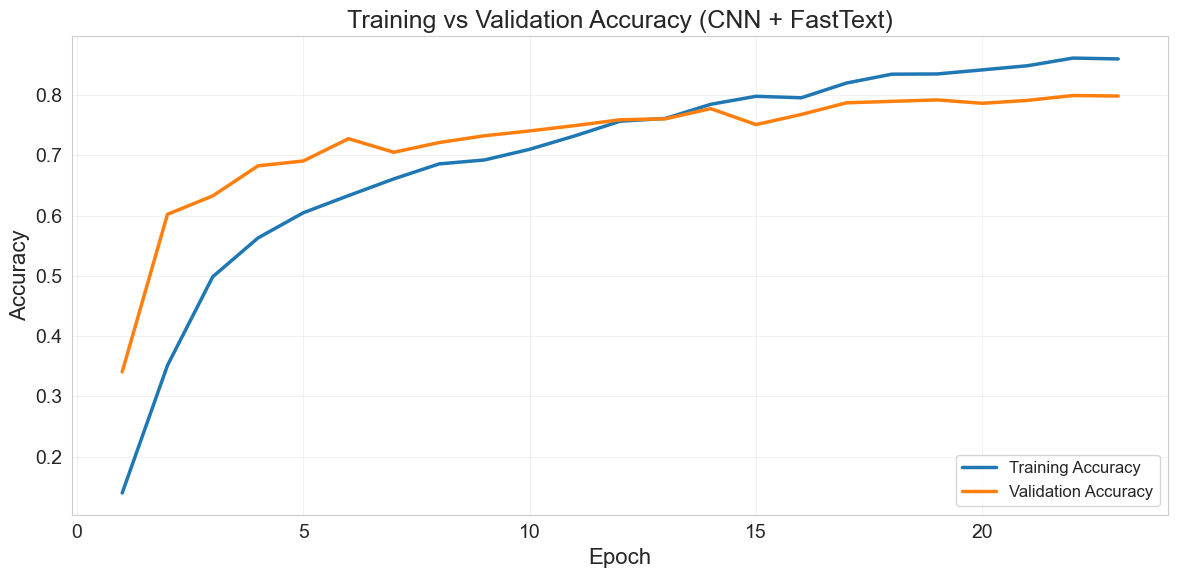

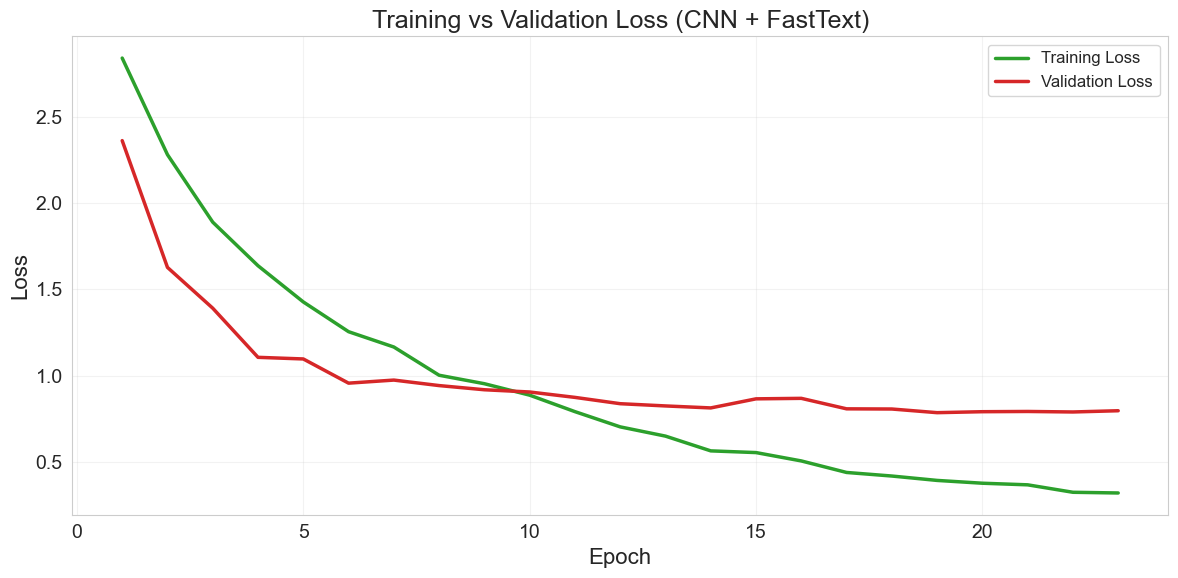

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use clean professional style
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 12,
    "figure.figsize": (12, 6),
    "lines.linewidth": 2.5
})

# Extract training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# ============ PLOT 1: ACCURACY ================
plt.figure(figsize=(12, 6))
plt.plot(epochs, acc, label="Training Accuracy", color="#1f77b4")
plt.plot(epochs, val_acc, label="Validation Accuracy", color="#ff7f0e")

plt.title("Training vs Validation Accuracy (CNN + FastText)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ============ PLOT 2: LOSS ====================
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, label="Training Loss", color="#2ca02c")
plt.plot(epochs, val_loss, label="Validation Loss", color="#d62728")

plt.title("Training vs Validation Loss (CNN + FastText)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
